In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD ENRICHED DATASET
# ============================================================

df2 = pd.read_csv("enriched_transactions.csv")

# ============================================================
# KEEP THE OLD PYTHON COLUMN NAMES
# ============================================================
# Original columns retain their old names so all existing
# analysis / graph code continues to work.
#
# New geographic/bank columns are added at the end.

df2.columns = [
    "timestamp",
    "from_bank",
    "from_account",
    "to_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering",

    # NEW COLUMNS
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

# ============================================================
# PARSE TIMESTAMP
# ============================================================

df2["timestamp"] = pd.to_datetime(
    df2["timestamp"],
    # format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)

# ============================================================
# NUMERIC COLUMNS
# ============================================================

df2["amount_received"] = pd.to_numeric(
    df2["amount_received"],
    errors="coerce"
)

df2["amount_paid"] = pd.to_numeric(
    df2["amount_paid"],
    errors="coerce"
)

# ============================================================
# LAUNDERING FLAG
# ============================================================

df2["is_laundering"] = (
    df2["is_laundering"]
    .astype(str)
    .str.strip()
    .map({
        "1": True,
        "0": False,
        "True": True,
        "False": False
    })
)

# ============================================================
# CLEAN NEW LOCATION / BANK COLUMNS
# ============================================================

for col in [
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]:
    df2[col] = (
        df2[col]
        .astype(str)
        .str.strip()
        .replace("nan", np.nan)
    )

# ============================================================
# BASIC INFORMATION
# ============================================================

print("Dataset shape:", df2.shape)

print("\nColumns:")
print(df2.columns.tolist())

print("\nMissing values:")
display(df2.isna().sum().to_frame("Missing"))

print("\nDataset preview:")
display(df2.head())

ValueError: Length mismatch: Expected axis has 27 elements, new values have 15 elements

In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Total transactions : {len(df2):,}")
print(f"Total columns      : {len(df2.columns)}")

print("\nDate range:")
print(df2["timestamp"].min(), "→", df2["timestamp"].max())

print("\nUnique values:")
print(f"From banks        : {df2['from_bank'].nunique():,}")
print(f"To banks          : {df2['to_bank'].nunique():,}")
print(f"From accounts     : {df2['from_account'].nunique():,}")
print(f"To accounts       : {df2['to_account'].nunique():,}")
print(f"Payment formats   : {df2['payment_format'].nunique():,}")
print(f"Receiving currency: {df2['receiving_currency'].nunique():,}")
print(f"Payment currencies: {df2['payment_currency'].nunique():,}")

DATASET OVERVIEW
Total transactions : 6,924,049
Total columns      : 15

Date range:
2022-09-01 00:00:00 → 2022-09-17 15:28:00

Unique values:
From banks        : 41,814
To banks          : 21,588
From accounts     : 681,281
To accounts       : 576,176
Payment formats   : 7
Receiving currency: 15
Payment currencies: 15


In [ ]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("\nMissing values:")
display(
    df2.isnull()
       .sum()
       .sort_values(ascending=False)
       .to_frame("missing_count")
)

print("\nDuplicate rows:")
print(df2.duplicated().sum())

print("\nDuplicate transaction-like records:")
print(
    df2.duplicated(
        subset=[
            "timestamp",
            "from_bank",
            "from_account",
            "to_bank",
            "to_account",
            "amount_paid"
        ]
    ).sum()
)

print("\nInvalid timestamps:")
print(df2["timestamp"].isna().sum())

print("\nInvalid amounts:")
print(
    ((df2["amount_paid"] < 0) |
     (df2["amount_paid"] < 0)).sum()
)

DATA QUALITY CHECK

Missing values:


,missing_count
timestamp,0
from_bank,0
from_account,0
to_bank,0
to_account,0
amount_received,0
receiving_currency,0
amount_paid,0
payment_currency,0
payment_format,0



Duplicate rows:
8

Duplicate transaction-like records:
14

Invalid timestamps:
0

Invalid amounts:
0


In [ ]:
total = len(df2)

laundering = df2["is_laundering"].sum()
non_laundering = total - laundering

print("=" * 60)
print("LAUNDERING SUMMARY")
print("=" * 60)

print(f"Total transactions       : {total:,}")
print(f"Laundering transactions  : {laundering:,}")
print(f"Non-laundering           : {non_laundering:,}")

print(
    f"Laundering ratio         : "
    f"{laundering / total:.4%}"
)

print(
    f"Non-laundering ratio     : "
    f"{non_laundering / total:.4%}"
)

print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

display(
    df2.groupby("is_laundering")[
        ["amount_received", "amount_paid"]
    ].describe()
)

amount_summary = (
    df2.groupby("is_laundering")
       .agg(
           transaction_count=("timestamp", "count"),
           total_received=("amount_received", "sum"),
           average_received=("amount_received", "mean"),
           median_received=("amount_received", "median"),
           max_received=("amount_received", "max"),
           total_paid=("amount_paid", "sum"),
           average_paid=("amount_paid", "mean")
       )
)

display(amount_summary)

format_summary = (
    df2.groupby("payment_format")
       .agg(
           total_transactions=("timestamp", "count"),
           laundering_transactions=("is_laundering", "sum"),
           total_amount=("amount_received", "sum")
       )
)

format_summary["laundering_rate"] = (
    format_summary["laundering_transactions"] /
    format_summary["total_transactions"]
)

format_summary = format_summary.sort_values(
    "laundering_rate",
    ascending=False
)

display(format_summary)



LAUNDERING SUMMARY
Total transactions       : 6,924,049
Laundering transactions  : 3,565
Non-laundering           : 6,920,484
Laundering ratio         : 0.0515%
Non-laundering ratio     : 99.9485%
TRANSACTION AMOUNT ANALYSIS


amount_received                                                 \
                        count          mean           std       min      25%   
is_laundering                                                                  
False               6920484.0  6.325456e+06  2.105913e+09  0.000001   174.05   
True                   3565.0  3.626202e+06  6.220028e+07  0.001136  1461.77   

                                               amount_paid                \
                   50%       75%           max       count          mean   
is_laundering                                                              
False          1396.20  12294.03  3.644854e+12   6920484.0  4.676577e+06   
True           4295.24  13971.04  2.473295e+09      3565.0  3.626202e+06   

                                                                   \
                        std       min      25%      50%       75%   
is_laundering                                                       
False          1.544496e+09  0.000001   175.22  1398.16  12224.89   
True           6.220028e+07  0.001136  1461.77  4295.24  13971.04   

                             
                        max  
is_laundering                
False          3.644854e+12  
True           2.473295e+09

,transaction_count,total_received,average_received,median_received,max_received,total_paid,average_paid
is_laundering,,,,,,,
False,6920484,4.377522e+13,6.325456e+06,1396.20,3.644854e+12,3.236417e+13,4.676577e+06
True,3565,1.292741e+10,3.626202e+06,4295.24,2.473295e+09,1.292741e+10,3.626202e+06


,total_transactions,laundering_transactions,total_amount,laundering_rate
payment_format,,,,
ACH,796581,2611,1.733022e+13,0.003278
Bitcoin,309208,110,1.429660e+07,0.000356
Cash,655688,124,4.332097e+12,0.000189
Cheque,2503158,459,1.871716e+13,0.000183
Credit Card,1780389,261,1.288668e+11,0.000147
Reinvestment,650458,0,1.560993e+12,0.000000
Wire,228567,0,1.718789e+12,0.000000


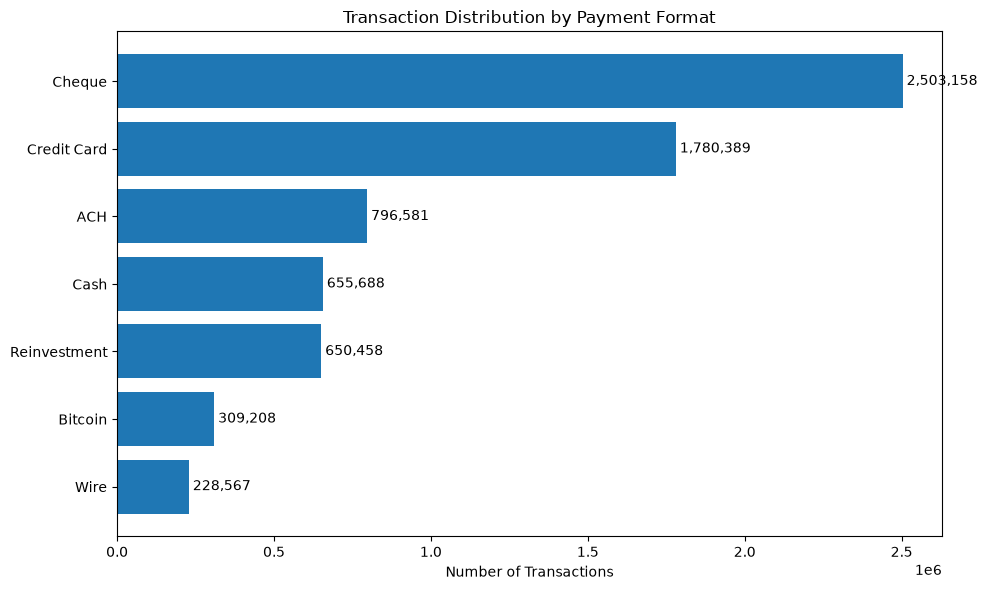

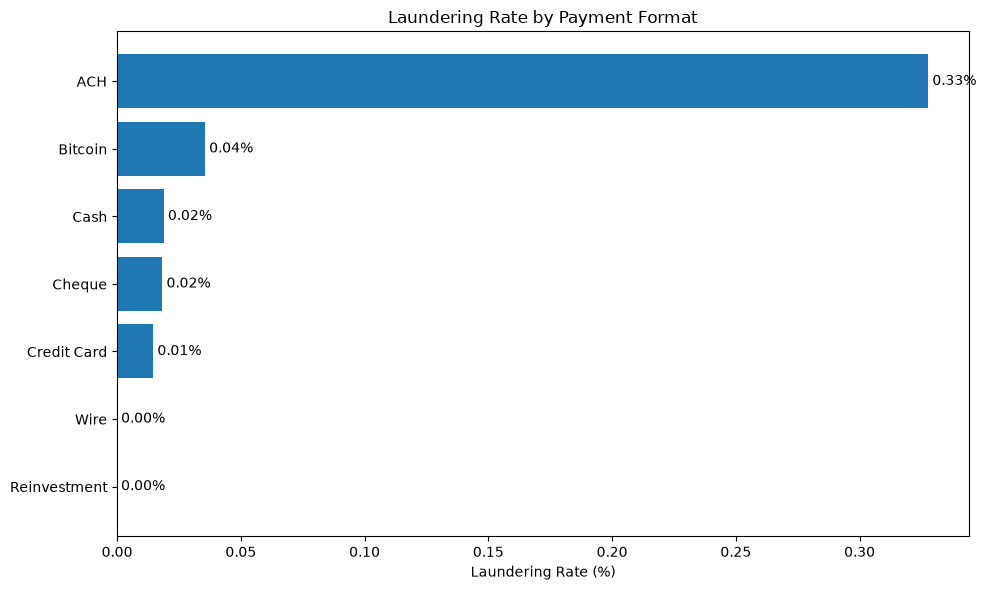

is_laundering,legitimate,laundering,total
day,,,
1,1524497,310,1524807
2,1027408,350,1027758
3,283034,292,283326
4,282185,291,282476
5,657027,370,657397
6,656790,380,657170
7,658136,368,658504
8,657536,402,657938
9,891206,367,891573


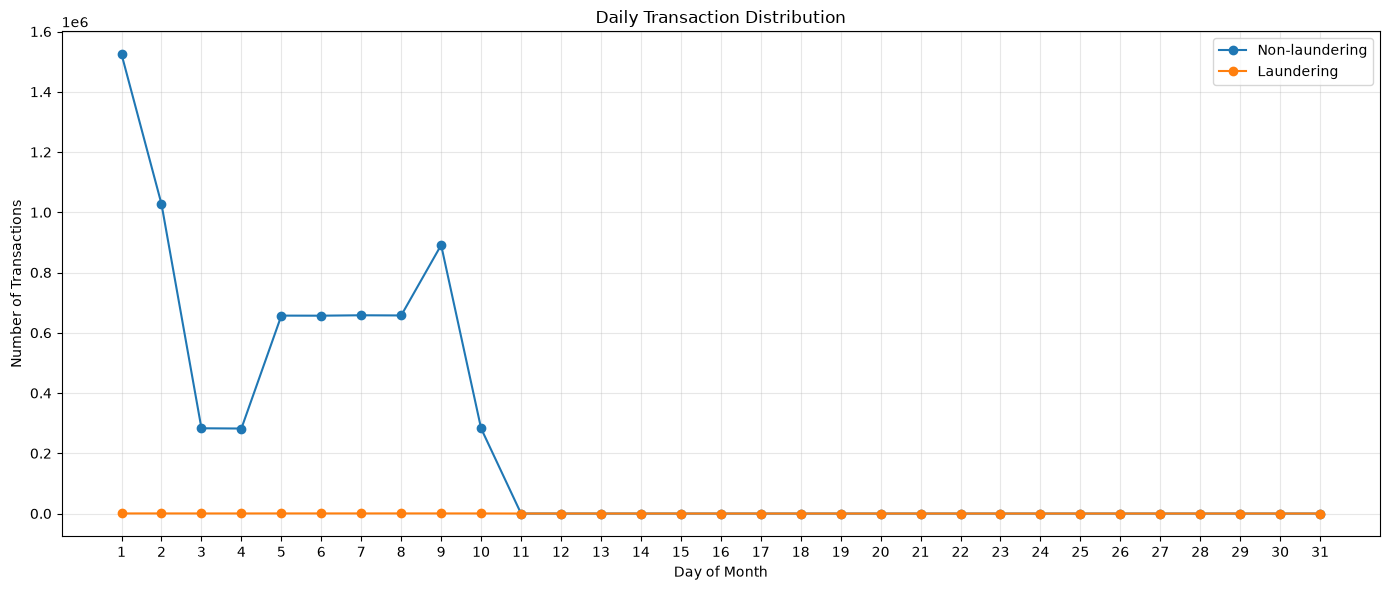

payment_format,ACH,Bitcoin,Cash,Cheque,Credit Card,Reinvestment,Wire
day,,,,,,,
1,115060,66446,89494,344907,224438,650458,34004
2,135492,45082,113096,413059,283504,0,37525
3,39391,12739,27289,106793,87507,0,9607
4,38519,12789,27289,106762,87510,0,9607
5,77263,30184,68988,266374,190171,0,24417
6,77121,30105,68988,266358,190174,0,24424
7,78396,30154,68988,266384,190173,0,24409
8,77980,30057,68987,266346,190169,0,24399
9,118276,38763,95280,359462,249236,0,30556


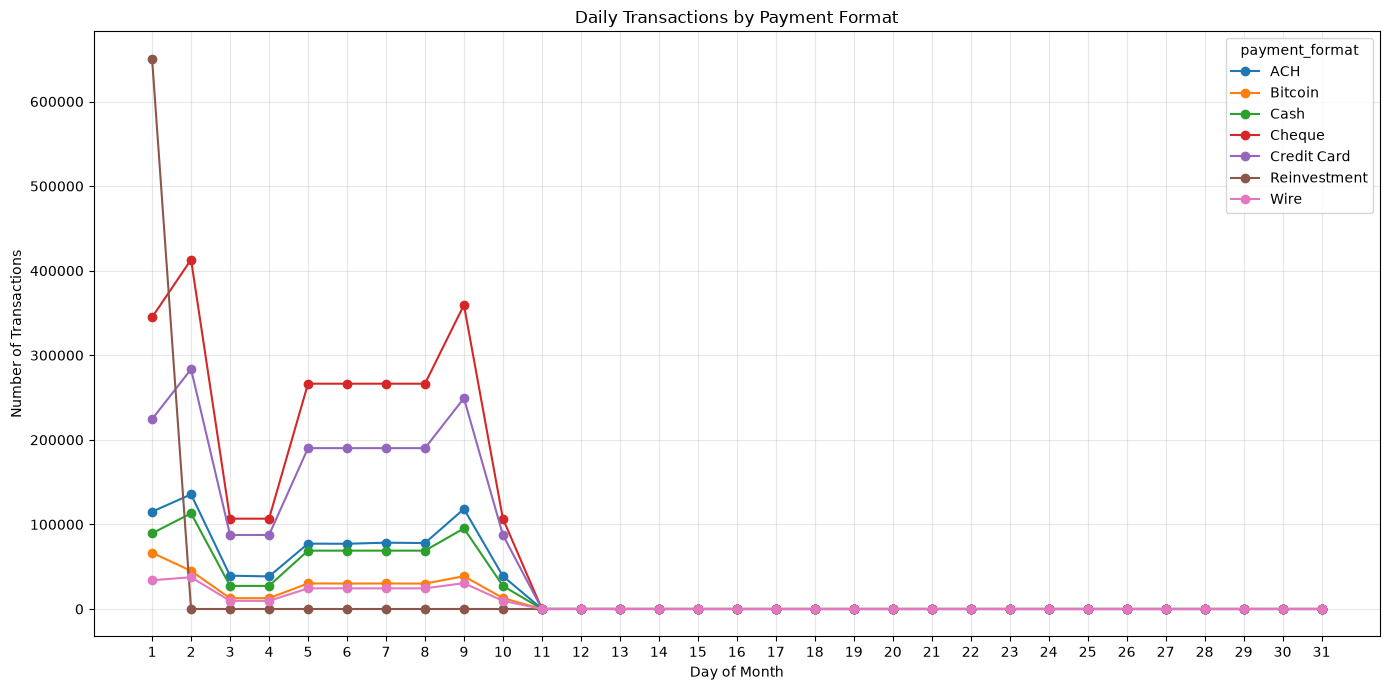

In [ ]:
format_counts = (
    df2["payment_format"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    format_counts.index,
    format_counts.values
)

plt.title("Transaction Distribution by Payment Format")
plt.xlabel("Number of Transactions")

for i, value in enumerate(format_counts.values):
    plt.text(
        value,
        i,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

format_rate = (
    df2.groupby("payment_format")["is_laundering"]
       .mean()
       .sort_values(ascending=True)
       * 100
)

plt.figure(figsize=(10, 6))

plt.barh(
    format_rate.index,
    format_rate.values
)

plt.title("Laundering Rate by Payment Format")
plt.xlabel("Laundering Rate (%)")

for i, value in enumerate(format_rate.values):
    plt.text(
        value,
        i,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

df2["day"] = df2["timestamp"].dt.day

daily_summary = (
    df2.groupby(["day", "is_laundering"])
       .size()
       .unstack(fill_value=0)
       .reindex(range(1, 32), fill_value=0)
)

daily_summary = daily_summary.rename(
    columns={
        False: "legitimate",
        True: "laundering"
    }
)

daily_summary["total"] = (
    daily_summary["legitimate"] +
    daily_summary["laundering"]
)

display(daily_summary)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_summary.index,
    daily_summary["legitimate"],
    marker="o",
    label="Non-laundering"
)

plt.plot(
    daily_summary.index,
    daily_summary["laundering"],
    marker="o",
    label="Laundering"
)

plt.title("Daily Transaction Distribution")
plt.xlabel("Day of Month")
plt.ylabel("Number of Transactions")

plt.xticks(range(1, 32))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

daily_format = (
    df2.groupby(["day", "payment_format"])
       .size()
       .unstack(fill_value=0)
       .reindex(range(1, 32), fill_value=0)
)

display(daily_format)

daily_format.plot(
    figsize=(14, 7),
    marker="o"
)

plt.title("Daily Transactions by Payment Format")
plt.xlabel("Day of Month")
plt.ylabel("Number of Transactions")
plt.xticks(range(1, 32))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



is_laundering,legitimate,laundering,total
hour,,,
0,868873,131,869004
1,263288,112,263400
2,261563,134,261697
3,263777,143,263920
4,262450,127,262577
5,263235,133,263368
6,264348,122,264470
7,262048,147,262195
8,262004,153,262157


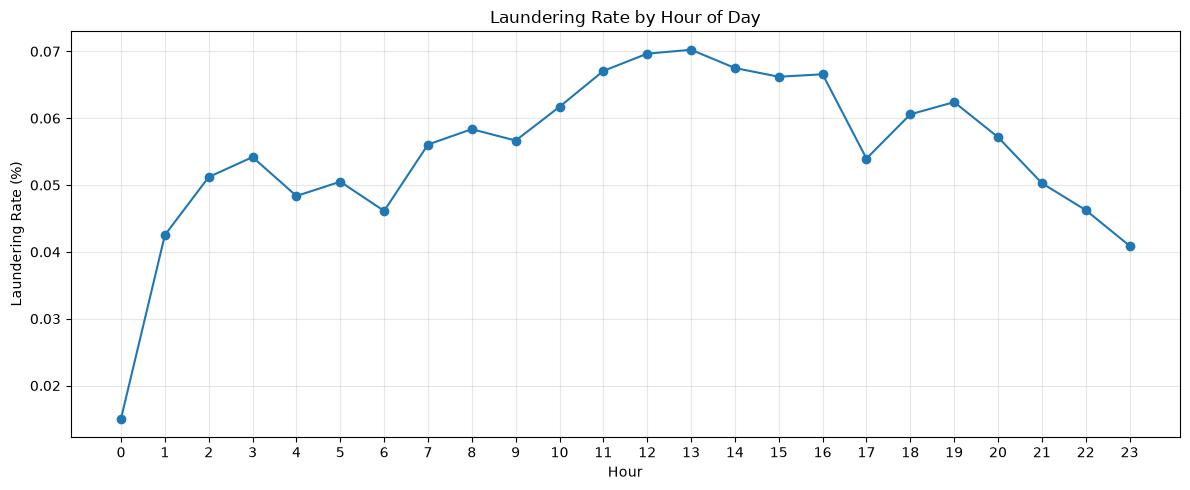

,transactions,laundering_transactions,total_amount,laundering_rate
from_bank,,,,
70,609991,850,2.119353e+12,0.001393
11,123456,83,1.026101e+11,0.000672
20,120114,78,1.561607e+12,0.000649
12,64465,64,3.886775e+11,0.000993
1217,33649,47,5.424790e+10,0.001397
14,64681,36,1.281526e+11,0.000557
224,34009,34,1.983128e+10,0.001000
423,26691,28,8.767922e+09,0.001049
1595,23470,27,3.296693e+10,0.001150


,transactions,laundering_transactions,total_amount,average_amount,laundering_rate
from_account,,,,,
10042B660,222037,314,7.311374e+10,3.292863e+05,0.001414
10042B6A8,138777,196,3.745144e+10,2.698678e+05,0.001412
10042B6F0,42385,48,1.059043e+11,2.498627e+06,0.001132
10042BA08,22417,39,2.331884e+10,1.040230e+06,0.001740
10042B780,30802,32,7.291811e+11,2.367317e+07,0.001039
10042BA51,28932,31,7.629107e+05,2.636910e+01,0.001071
10042B9C0,16266,29,2.743770e+10,1.686813e+06,0.001783
10042B738,18213,28,9.242958e+11,5.074923e+07,0.001537
10042B858,15684,27,6.038723e+09,3.850244e+05,0.001721


Unique sender accounts   : 681,281
Unique receiver accounts : 576,176
Accounts appearing on BOTH sides: 551,554
Laundering accounts appearing as both sender and receiver: 382


In [ ]:
df2["hour"] = df2["timestamp"].dt.hour

hourly = (
    df2.groupby(["hour", "is_laundering"])
       .size()
       .unstack(fill_value=0)
       .reindex(range(24), fill_value=0)
)

hourly = hourly.rename(
    columns={
        False: "legitimate",
        True: "laundering"
    }
)

hourly["total"] = (
    hourly["legitimate"] +
    hourly["laundering"]
)

display(hourly)

hourly_rate = (
    df2.groupby("hour")["is_laundering"]
       .mean()
       * 100
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_rate.index,
    hourly_rate.values,
    marker="o"
)

plt.title("Laundering Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Laundering Rate (%)")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
bank_summary = (
    df2.groupby("from_bank")
       .agg(
           transactions=("timestamp", "count"),
           laundering_transactions=("is_laundering", "sum"),
           total_amount=("amount_received", "sum")
       )
)

bank_summary["laundering_rate"] = (
    bank_summary["laundering_transactions"] /
    bank_summary["transactions"]
)

bank_summary = bank_summary.sort_values(
    "laundering_transactions",
    ascending=False
)

display(bank_summary.head(30))

account_summary = (
    df2.groupby("from_account")
       .agg(
           transactions=("timestamp", "count"),
           laundering_transactions=("is_laundering", "sum"),
           total_amount=("amount_received", "sum"),
           average_amount=("amount_received", "mean")
       )
)

account_summary["laundering_rate"] = (
    account_summary["laundering_transactions"] /
    account_summary["transactions"]
)

display(
    account_summary
    .sort_values("laundering_transactions", ascending=False)
    .head(30)
)

from_accounts = set(df2["from_account"].dropna())
to_accounts = set(df2["to_account"].dropna())

both = from_accounts.intersection(to_accounts)

print(f"Unique sender accounts   : {len(from_accounts):,}")
print(f"Unique receiver accounts : {len(to_accounts):,}")
print(f"Accounts appearing on BOTH sides: {len(both):,}")


laundering_df = df2[
    df2["is_laundering"] == True
]

laundering_from = set(
    laundering_df["from_account"].dropna()
)

laundering_to = set(
    laundering_df["to_account"].dropna()
)

laundering_both = laundering_from.intersection(
    laundering_to
)

print(
    "Laundering accounts appearing "
    f"as both sender and receiver: {len(laundering_both):,}"
)

In [ ]:
%pip install networkx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import networkx as nx

# # Create directed transaction graph
# G = nx.DiGraph()

# for _, row in df2.iterrows():

#     src = row["from_account"]
#     dst = row["to_account"]

#     if pd.isna(src) or pd.isna(dst):
#         continue

#     # Add/update edge
#     if G.has_edge(src, dst):
#         G[src][dst]["transaction_count"] += 1
#         G[src][dst]["total_amount"] += row["amount_received"]

#         if row["is_laundering"]:
#             G[src][dst]["laundering_count"] += 1
#     else:
#         G.add_edge(
#             src,
#             dst,
#             transaction_count=1,
#             total_amount=row["amount_received"],
#             laundering_count=int(row["is_laundering"])
#         )

# print("Graph created")

# print(f"Nodes  : {G.number_of_nodes():,}")
# print(f"Edges  : {G.number_of_edges():,}")

In [ ]:
# print("=" * 60)
# print("TRANSACTION GRAPH STATISTICS")
# print("=" * 60)

# print(f"Number of accounts : {G.number_of_nodes():,}")
# print(f"Number of connections : {G.number_of_edges():,}")

# print(f"Average degree : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# # Accounts involved in laundering transactions
# laundering_rows = df2[df2["is_laundering"] == True]

# laundering_accounts = set(
#     laundering_rows["from_account"]
# ).union(
#     set(laundering_rows["to_account"])
# )

# print(f"Laundering-involved accounts : {len(laundering_accounts):,}")

# print(f"Graph density : {nx.density(G):.6f}")

# print("=" * 60)
# print("TRANSACTION GRAPH STATISTICS")
# print("=" * 60)

# print(f"Number of accounts : {G.number_of_nodes():,}")
# print(f"Number of connections : {G.number_of_edges():,}")

# print(f"Average degree : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# # Accounts involved in laundering transactions
# laundering_rows = df2[df2["is_laundering"] == True]

# laundering_accounts = set(
#     laundering_rows["from_account"]
# ).union(
#     set(laundering_rows["to_account"])
# )

# print(f"Laundering-involved accounts : {len(laundering_accounts):,}")

# print(f"Graph density : {nx.density(G):.6f}")

# degree_df = pd.DataFrame({
#     "account": list(G.nodes()),
#     "degree": [G.degree(n) for n in G.nodes()],
#     "in_degree": [G.in_degree(n) for n in G.nodes()],
#     "out_degree": [G.out_degree(n) for n in G.nodes()]
# })

# degree_df = degree_df.sort_values(
#     "degree",
#     ascending=False
# )

# display(degree_df.head(30))

In [ ]:
# # Keep laundering-related edges
# laundering_edges = []

# for u, v, data in G.edges(data=True):

#     if data["laundering_count"] > 0:
#         laundering_edges.append(
#             (u, v)
#         )

# G_laundering = G.edge_subgraph(
#     laundering_edges
# ).copy()

# print("Laundering subgraph:")
# print(f"Nodes : {G_laundering.number_of_nodes():,}")
# print(f"Edges : {G_laundering.number_of_edges():,}")

# plt.figure(figsize=(16, 12))

# # If graph is very large, visualize only the largest connected component
# if G_laundering.number_of_nodes() > 100:

#     components = sorted(
#         nx.weakly_connected_components(G_laundering),
#         key=len,
#         reverse=True
#     )

#     # Take largest component
#     nodes_to_plot = components[0]

#     G_plot = G_laundering.subgraph(
#         nodes_to_plot
#     ).copy()

#     print(
#         f"Graph too large — showing largest component "
#         f"with {len(G_plot.nodes()):,} accounts."
#     )

# else:
#     G_plot = G_laundering


# # Layout
# pos = nx.spring_layout(
#     G_plot,
#     seed=42,
#     k=1.5,
#     iterations=100
# )

# # Node size based on degree
# node_sizes = [
#     100 + G_plot.degree(n) * 80
#     for n in G_plot.nodes()
# ]

# # Draw nodes
# nx.draw_networkx_nodes(
#     G_plot,
#     pos,
#     node_size=node_sizes,
#     alpha=0.85
# )

# # Draw edges
# nx.draw_networkx_edges(
#     G_plot,
#     pos,
#     arrows=True,
#     arrowsize=12,
#     alpha=0.5,
#     width=1
# )

# # Labels
# nx.draw_networkx_labels(
#     G_plot,
#     pos,
#     font_size=7
# )

# plt.title(
#     "Suspicious Transaction Network",
#     fontsize=16
# )

# plt.axis("off")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(16, 12))

# pos = nx.spring_layout(
#     G_plot,
#     seed=42,
#     k=1.5,
#     iterations=100
# )

# # Nodes involved in laundering
# laundering_nodes = set(
#     laundering_rows["from_account"]
# ).union(
#     laundering_rows["to_account"]
# )

# normal_nodes = [
#     n for n in G_plot.nodes()
#     if n not in laundering_nodes
# ]

# suspicious_nodes = [
#     n for n in G_plot.nodes()
#     if n in laundering_nodes
# ]

# # Normal nodes
# nx.draw_networkx_nodes(
#     G_plot,
#     pos,
#     nodelist=normal_nodes,
#     node_size=120,
#     alpha=0.5
# )

# # Suspicious nodes
# nx.draw_networkx_nodes(
#     G_plot,
#     pos,
#     nodelist=suspicious_nodes,
#     node_size=350,
#     node_color="red",
#     alpha=0.85
# )

# # Edges
# nx.draw_networkx_edges(
#     G_plot,
#     pos,
#     arrows=True,
#     arrowsize=12,
#     alpha=0.35
# )

# # Labels only for suspicious nodes
# nx.draw_networkx_labels(
#     G_plot,
#     pos,
#     labels={
#         n: n for n in suspicious_nodes
#     },
#     font_size=8
# )

# plt.title(
#     "Transaction Graph — Laundering Accounts Highlighted",
#     fontsize=16
# )

# plt.axis("off")
# plt.tight_layout()
# plt.show()

# # Find laundering-related paths of length 2–4

# paths = []

# for source in G_laundering.nodes():

#     for target in G_laundering.nodes():

#         if source == target:
#             continue

#         try:
#             for path in nx.all_simple_paths(
#                 G_laundering,
#                 source=source,
#                 target=target,
#                 cutoff=4
#             ):

#                 if len(path) >= 3:
#                     paths.append(path)

#                 if len(paths) >= 50:
#                     break

#         except nx.NetworkXNoPath:
#             pass

#         if len(paths) >= 50:
#             break

#     if len(paths) >= 50:
#         break


# print("Example transaction chains:\n")

# for path in paths[:20]:
#     print(" → ".join(path))

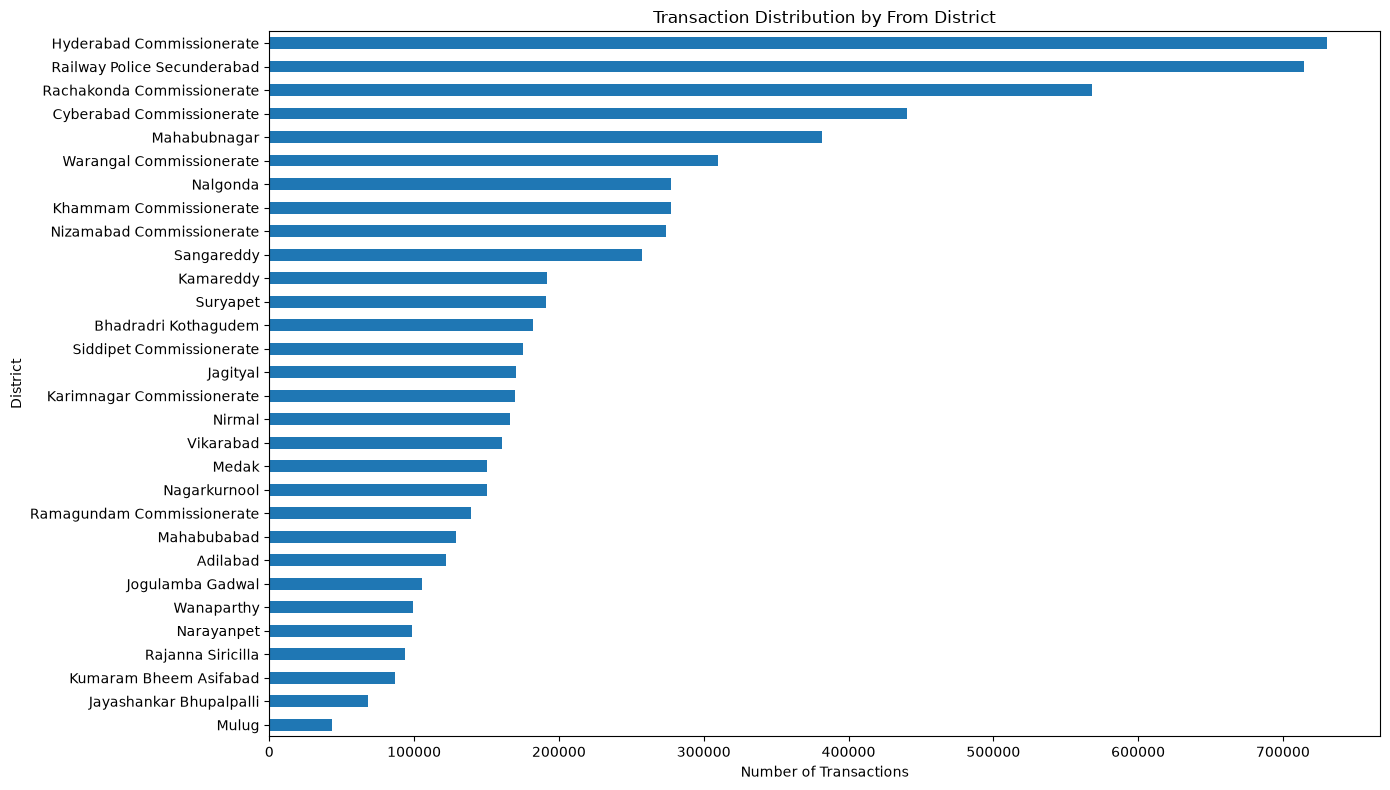

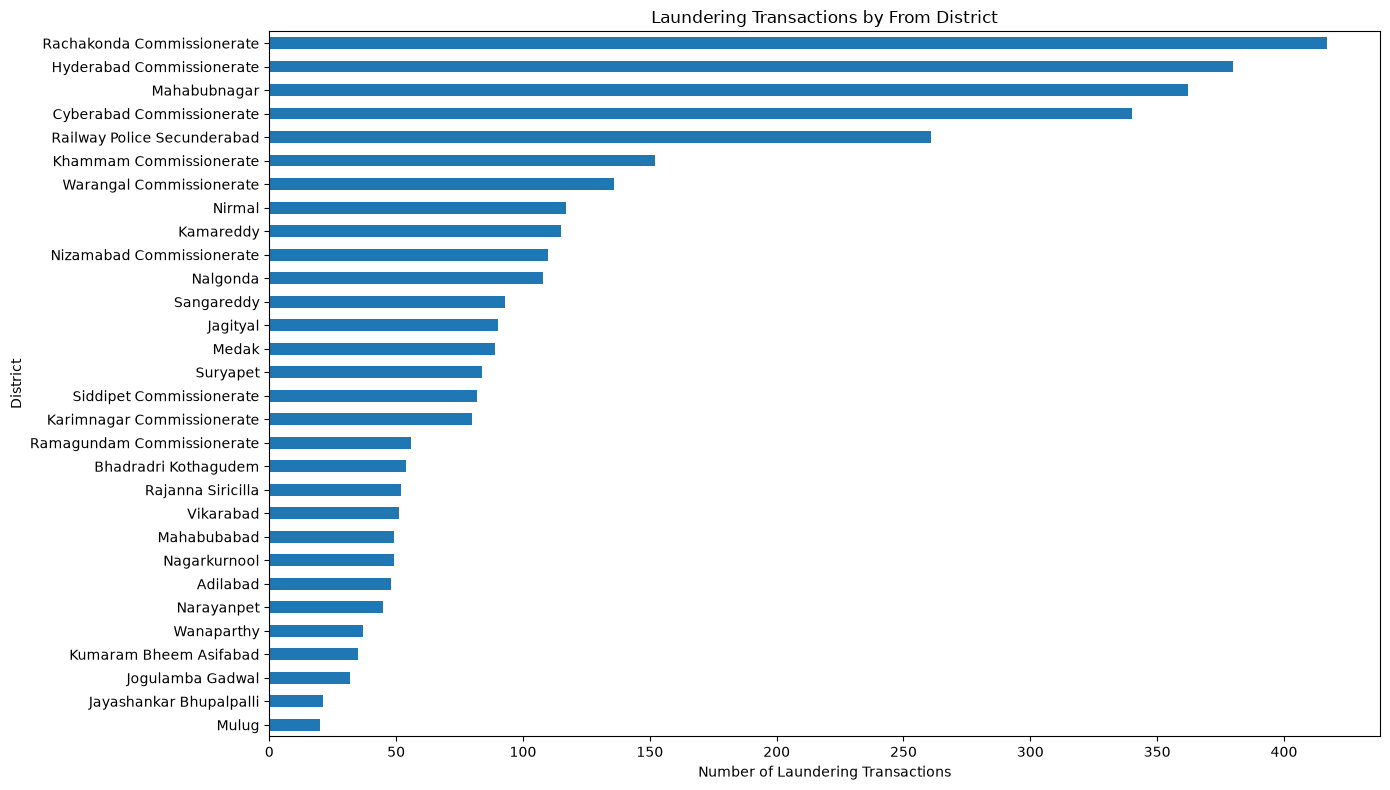

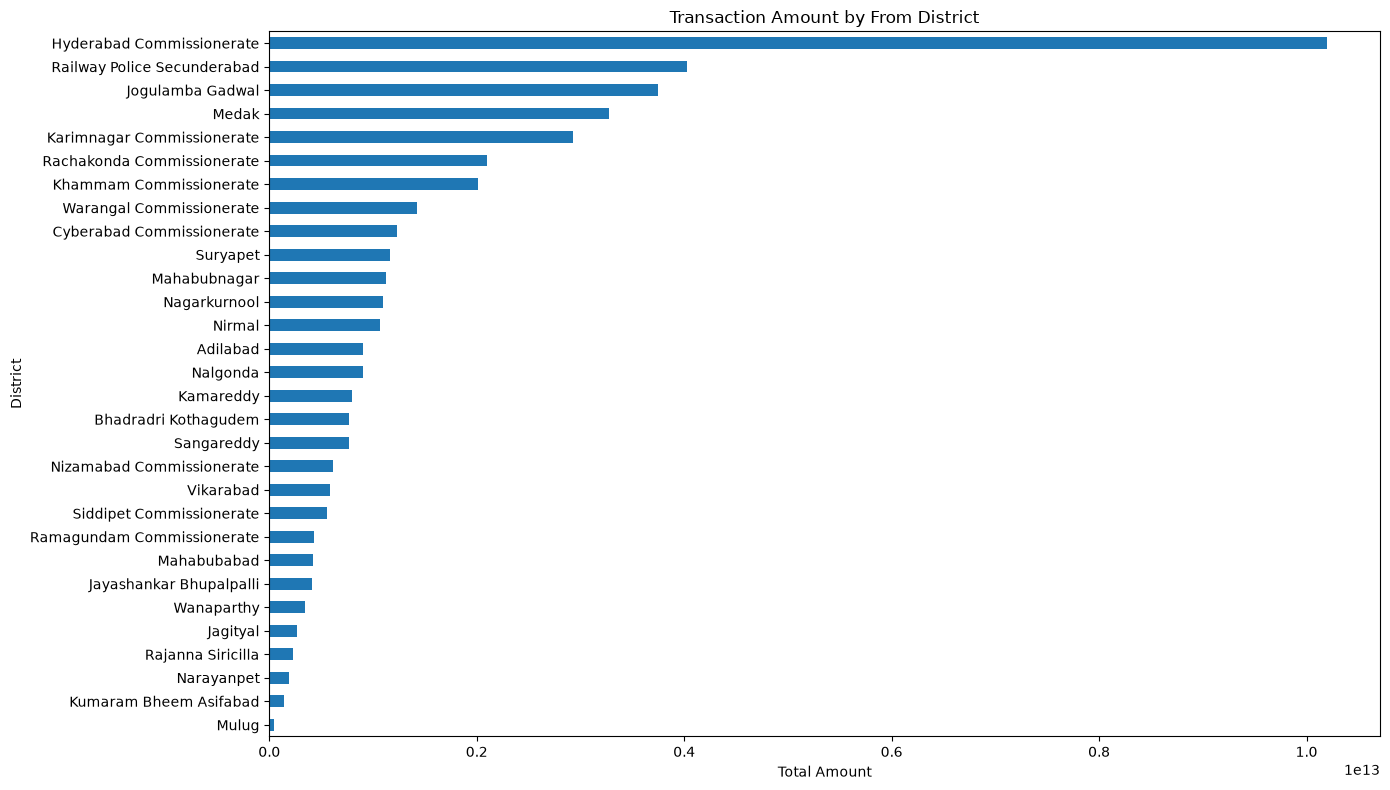

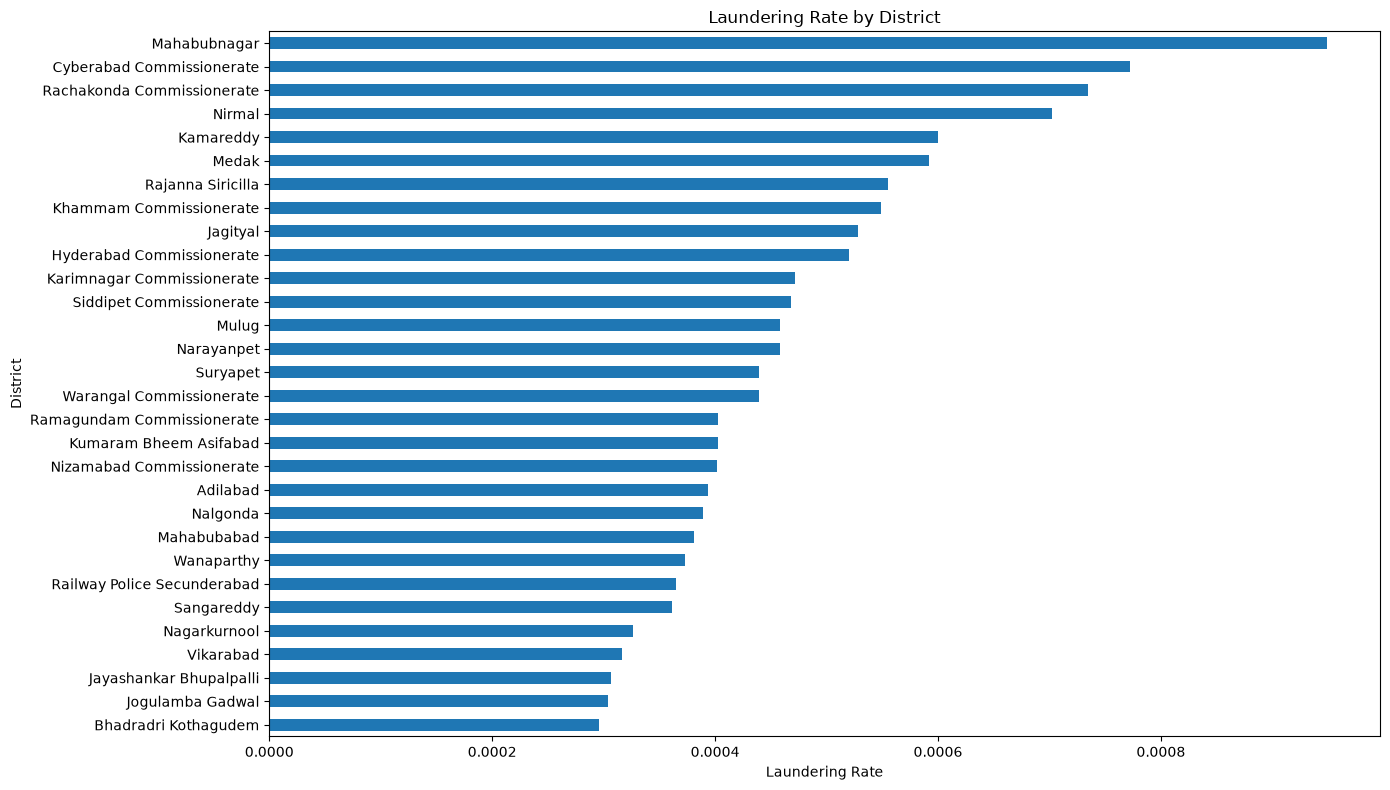

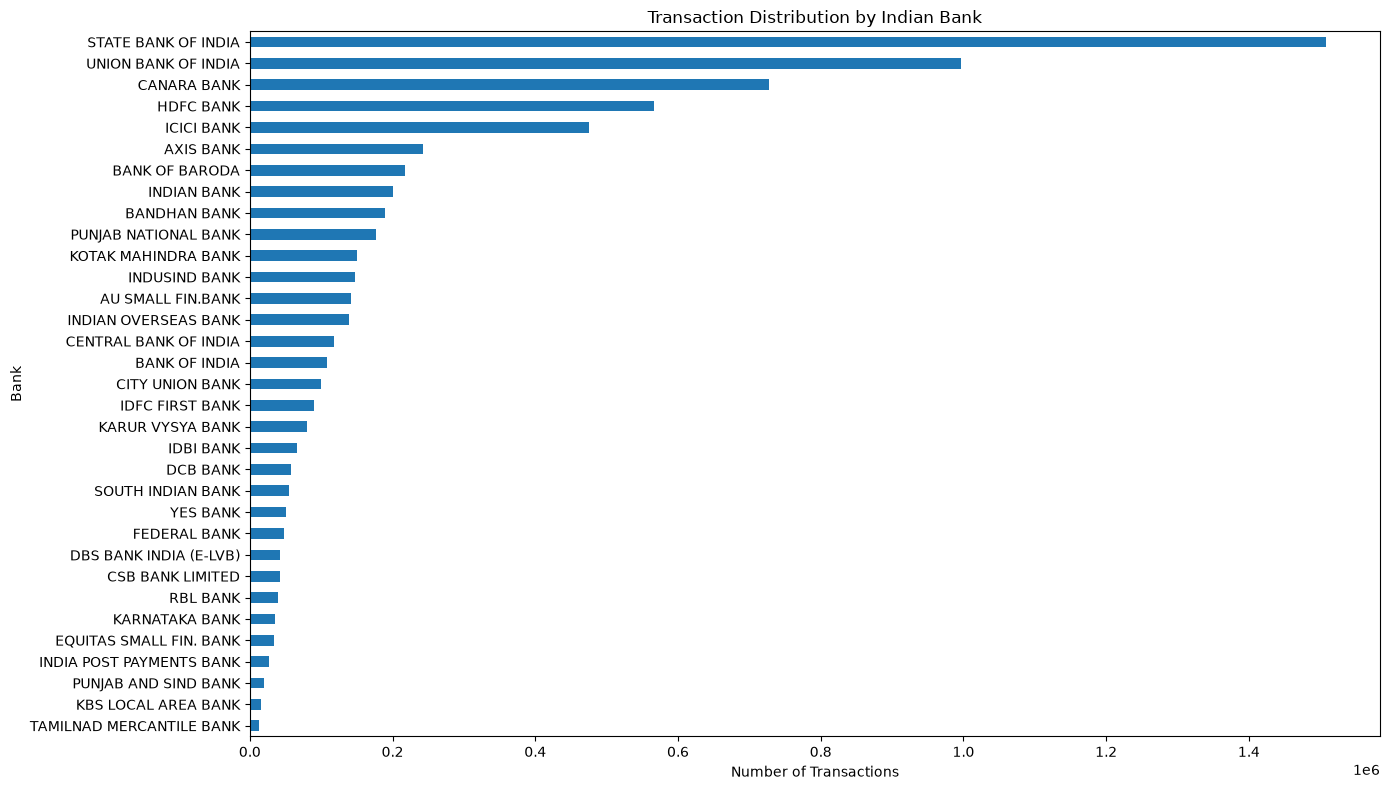

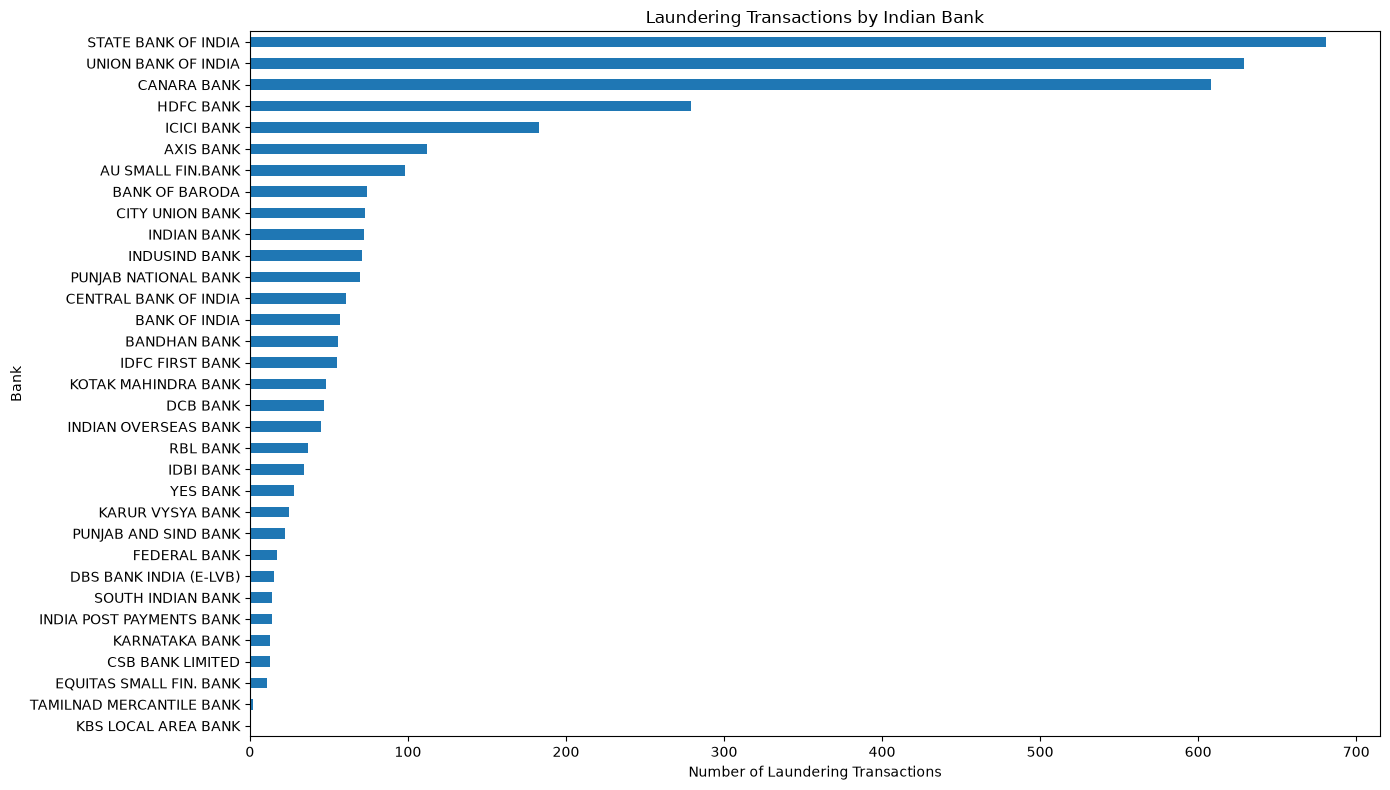

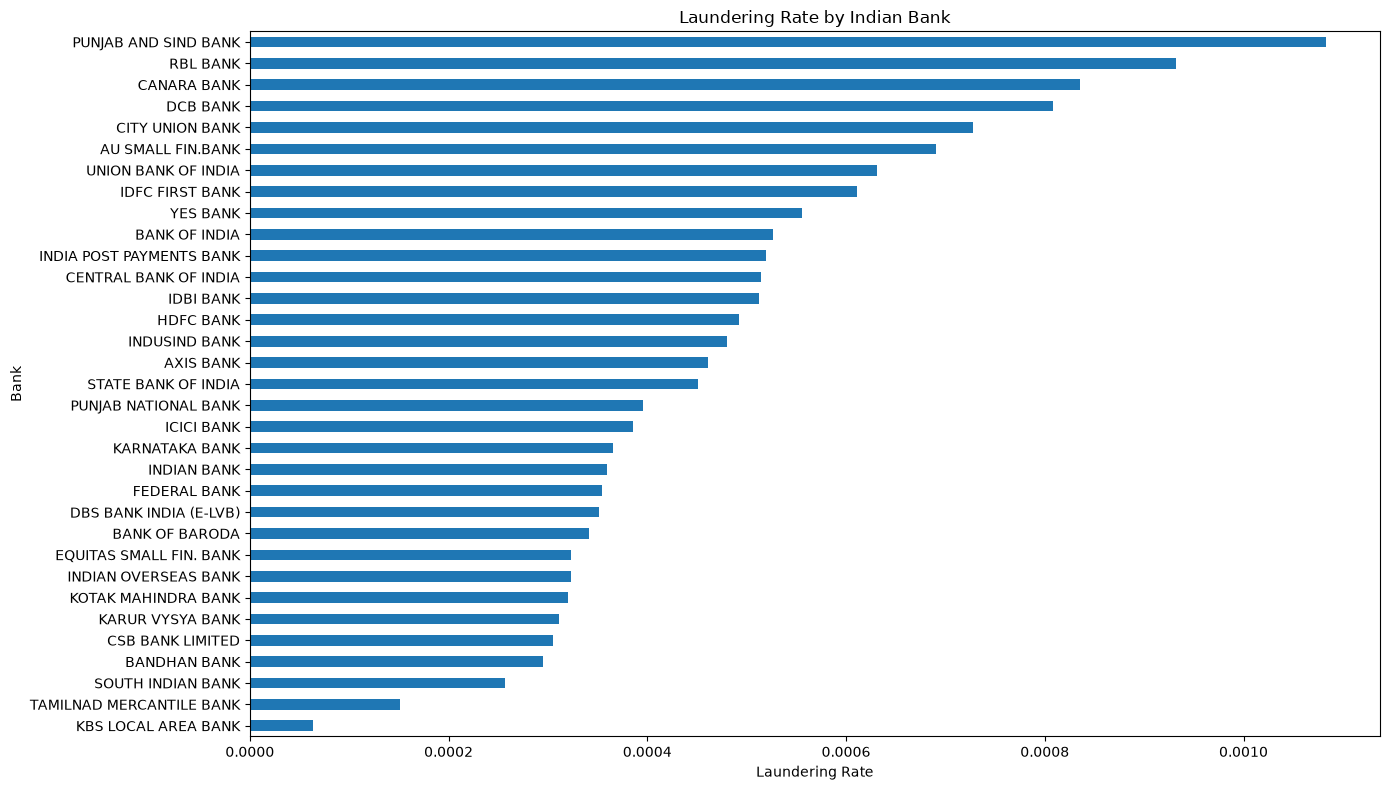

<Figure size 1600x1000 with 0 Axes>

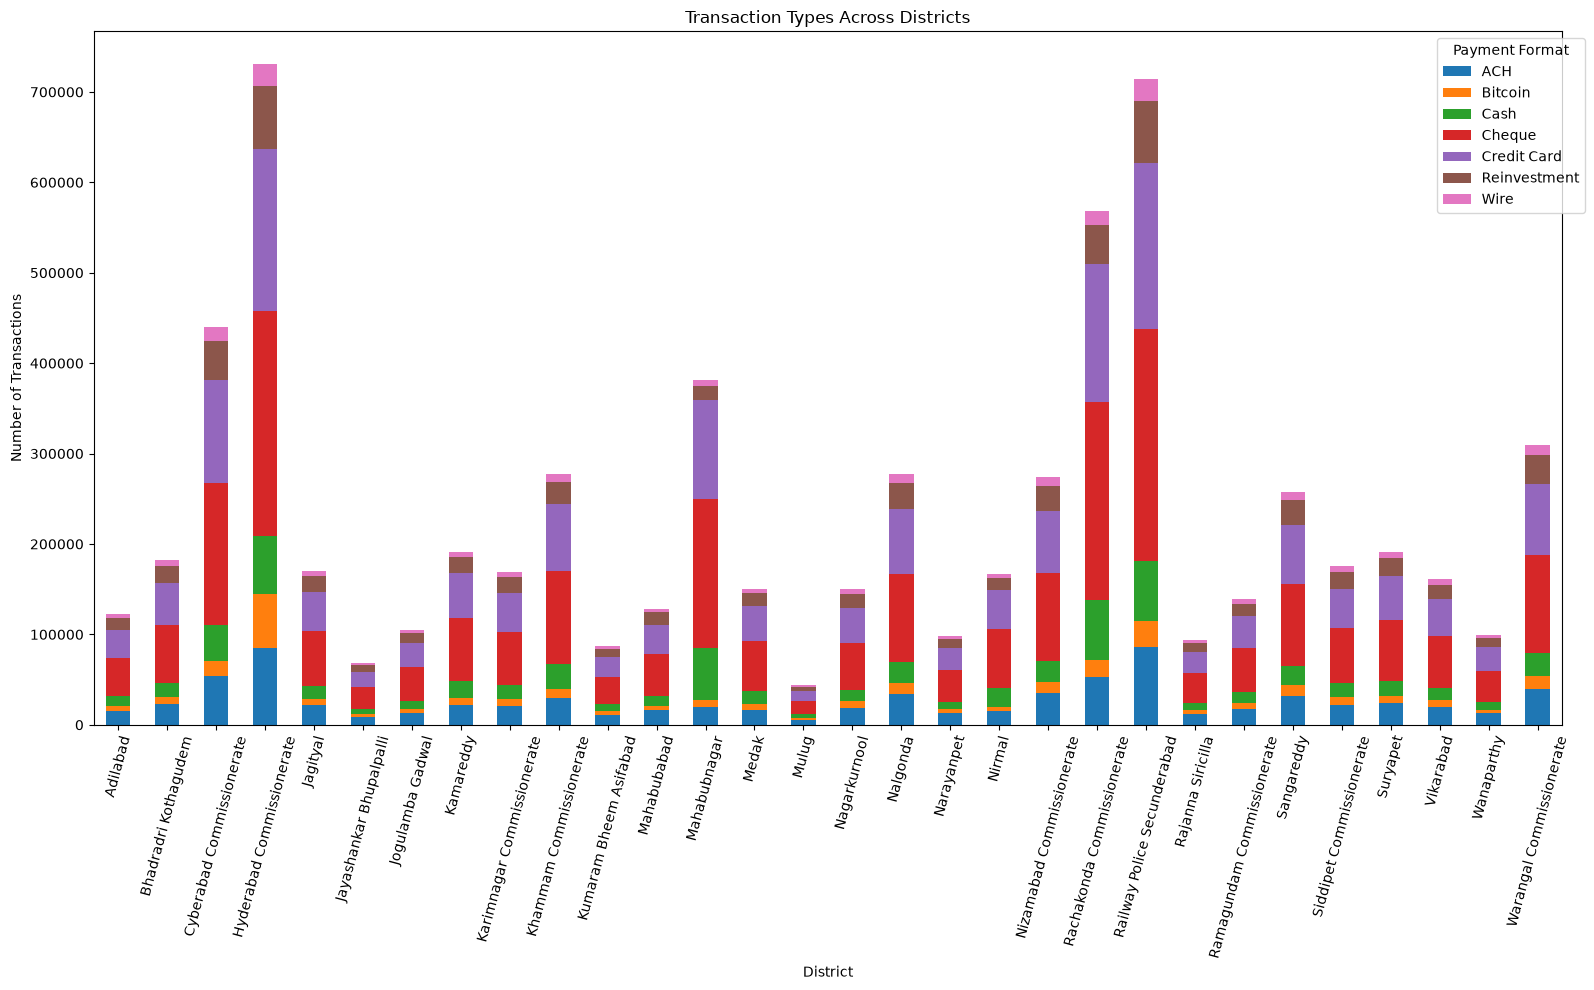

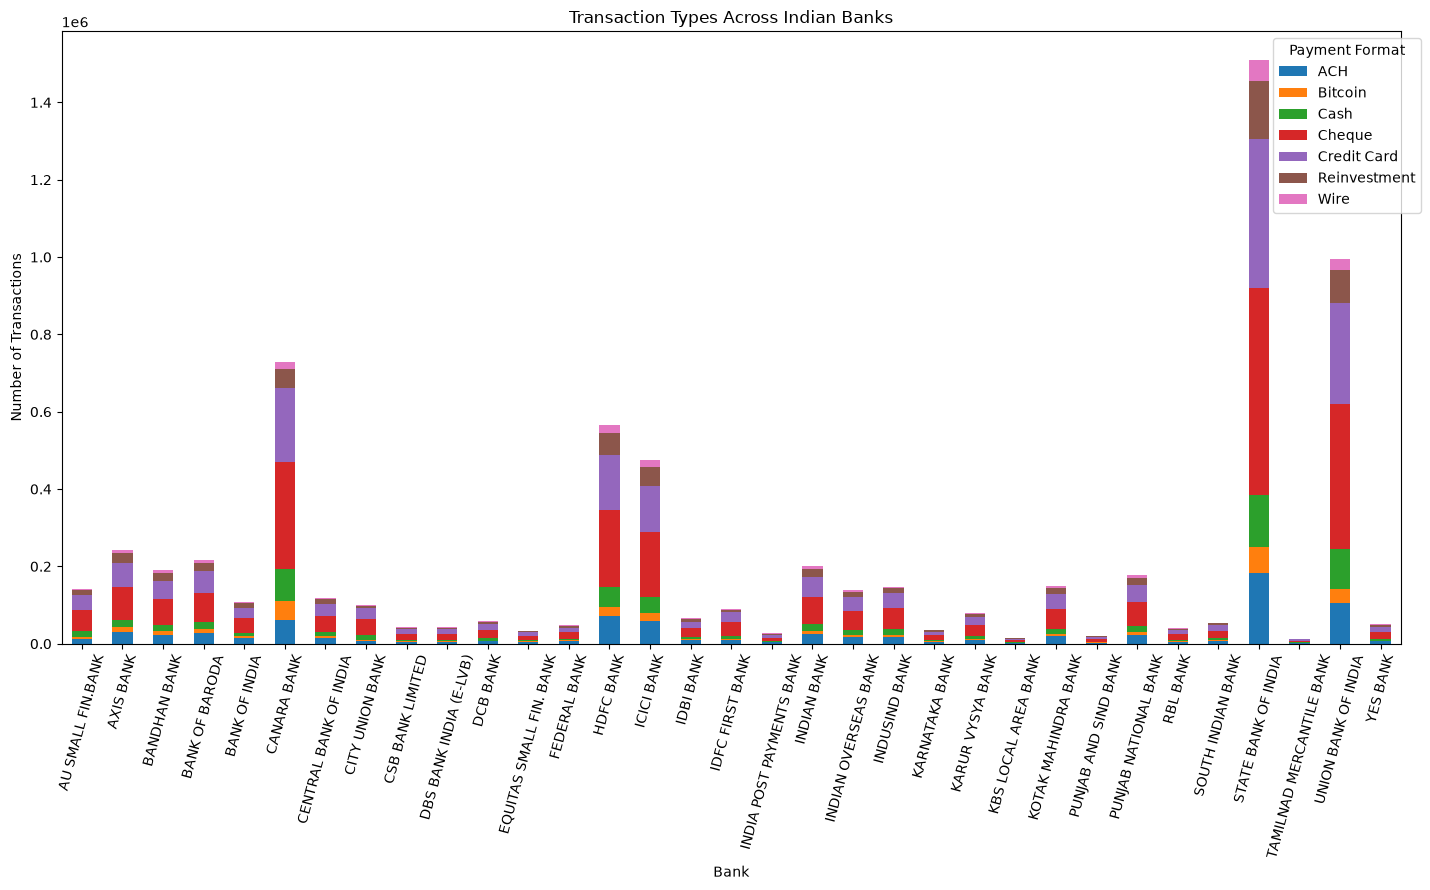

is_laundering,Legitimate,Laundering
from_district,,
Rachakonda Commissionerate,567498,417
Hyderabad Commissionerate,730131,380
Mahabubnagar,381039,362
Cyberabad Commissionerate,439777,340
Railway Police Secunderabad,714530,261
Khammam Commissionerate,276955,152
Warangal Commissionerate,309616,136
Nirmal,166412,117
Kamareddy,191433,115


is_laundering,Legitimate,Laundering
from_indian_bank,,
STATE BANK OF INDIA,1507669,681
UNION BANK OF INDIA,995410,629
CANARA BANK,726712,608
HDFC BANK,565904,279
ICICI BANK,474807,183
AXIS BANK,242585,112
AU SMALL FIN.BANK,141780,98
BANK OF BARODA,216751,74
CITY UNION BANK,100270,73


District-to-district transaction matrix:


to_district,Adilabad,Bhadradri Kothagudem,Cyberabad Commissionerate,Hyderabad Commissionerate,Jagityal,Jayashankar Bhupalpalli,Jogulamba Gadwal,Kamareddy,Karimnagar Commissionerate,Khammam Commissionerate,...,Rachakonda Commissionerate,Railway Police Secunderabad,Rajanna Siricilla,Ramagundam Commissionerate,Sangareddy,Siddipet Commissionerate,Suryapet,Vikarabad,Wanaparthy,Warangal Commissionerate
from_district,,,,,,,,,,,,,,,,,,,,,
Adilabad,17884,3065,6636,11044,3256,1297,1799,2613,3209,3919,...,6821,11812,1715,2112,4563,3118,3460,2301,2065,5385
Bhadradri Kothagudem,3107,27825,10955,16209,4259,1737,2630,4040,4341,5828,...,10857,16590,2615,3115,7152,4960,4810,4118,2345,7271
Cyberabad Commissionerate,7669,11055,78634,42100,10093,4327,6740,10438,10104,14937,...,26719,41179,5840,8234,15182,10310,11397,9984,6344,18260
Hyderabad Commissionerate,12757,18792,42056,154066,16631,7619,10960,17060,17524,24753,...,43604,69525,9659,14249,26740,17578,18804,16566,9812,30787
Jagityal,2881,4478,9764,15463,25926,1602,2634,3876,3993,5512,...,10205,15852,2063,3104,5764,4281,5035,3442,2611,7312
Jayashankar Bhupalpalli,1041,1601,3695,5887,1796,9846,966,1389,1478,2337,...,4202,6343,838,1565,2619,1781,1643,1617,582,2820
Jogulamba Gadwal,1892,2361,6736,9400,2566,1156,14746,2564,2690,3182,...,6019,10158,1143,2153,3701,2482,2850,2426,1260,4787
Kamareddy,2898,5318,10985,18054,4261,2150,2735,26386,4692,6563,...,11381,17415,2582,3118,7598,4923,5148,4242,2604,8377
Karimnagar Commissionerate,2537,4528,9518,15821,3799,1972,2298,4321,25637,5612,...,9936,16607,2081,3221,6077,4293,4487,3477,2102,6887


Top 25 district-to-district flows:


...

,from_indian_bank,to_indian_bank,transactions
986,STATE BANK OF INDIA,STATE BANK OF INDIA,490840
1054,UNION BANK OF INDIA,UNION BANK OF INDIA,221656
1052,UNION BANK OF INDIA,STATE BANK OF INDIA,204023
988,STATE BANK OF INDIA,UNION BANK OF INDIA,173980
194,CANARA BANK,STATE BANK OF INDIA,155608
970,STATE BANK OF INDIA,HDFC BANK,116459
442,HDFC BANK,HDFC BANK,114779
458,HDFC BANK,STATE BANK OF INDIA,113498
170,CANARA BANK,CANARA BANK,110896
962,STATE BANK OF INDIA,CANARA BANK,99670



DISTRICT SUMMARY


,transactions,total_amount,laundering_transactions,unique_accounts,unique_banks,laundering_rate
from_district,,,,,,
Rachakonda Commissionerate,567915,2.097626e+12,417,45207,33,0.000734
Hyderabad Commissionerate,730511,1.019847e+13,380,73058,33,0.000520
Mahabubnagar,381401,1.128911e+12,362,16977,33,0.000949
Cyberabad Commissionerate,440117,1.226512e+12,340,45233,33,0.000773
Railway Police Secunderabad,714791,4.030636e+12,261,72990,33,0.000365
Khammam Commissionerate,277107,2.010619e+12,152,25925,33,0.000549
Warangal Commissionerate,309752,1.423474e+12,136,33118,33,0.000439
Nirmal,166529,1.065482e+12,117,13143,33,0.000703
Kamareddy,191548,7.990627e+11,115,18042,33,0.000600



BANK SUMMARY


,transactions,total_amount,laundering_transactions,unique_accounts,unique_districts,laundering_rate
from_indian_bank,,,,,,
STATE BANK OF INDIA,1508350,1.017094e+13,681,157439,30,0.000451
UNION BANK OF INDIA,996039,3.347053e+12,629,88846,30,0.000632
CANARA BANK,727320,1.635401e+12,608,51522,30,0.000836
HDFC BANK,566183,3.312111e+12,279,60510,30,0.000493
ICICI BANK,474990,2.271768e+12,183,51876,30,0.000385
AXIS BANK,242697,7.870880e+12,112,26036,30,0.000461
AU SMALL FIN.BANK,141878,1.060728e+12,98,12024,30,0.000691
BANK OF BARODA,216825,5.292167e+11,74,23239,30,0.000341
CITY UNION BANK,100343,2.591569e+11,73,6075,30,0.000728


In [ ]:
# ============================================================
# TRANSACTION-LEVEL DISTRICT & BANK ANALYSIS
# Uses existing df2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DISTRICT DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

from_district_counts = (
    df2["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
from_district_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by From District")
plt.xlabel("Number of Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. DISTRICT DISTRIBUTION — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

district_laundering = (
    df2[df2["is_laundering"]]
    ["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by From District")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. DISTRICT — TOTAL AMOUNT
# ------------------------------------------------------------

district_amount = (
    df2.groupby("from_district")["amount_received"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_amount.sort_values().plot(kind="barh")
plt.title("Transaction Amount by From District")
plt.xlabel("Total Amount")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. DISTRICT — LAUNDERING RATE
# ------------------------------------------------------------

district_stats = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_received", "sum"),
        laundering_amount=(
            "amount_received",
            lambda x: x[df2.loc[x.index, "is_laundering"]].sum()
        )
    )
)

district_stats["laundering_rate"] = (
    district_stats["laundering_transactions"]
    / district_stats["transactions"]
)

district_stats = district_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
district_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by District")
plt.xlabel("Laundering Rate")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. BANK DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

bank_counts = (
    df2["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by Indian Bank")
plt.xlabel("Number of Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. BANK — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

bank_laundering = (
    df2[df2["is_laundering"]]
    ["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by Indian Bank")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. BANK — LAUNDERING RATE
# ------------------------------------------------------------

bank_stats = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_received", "sum")
    )
)

bank_stats["laundering_rate"] = (
    bank_stats["laundering_transactions"]
    / bank_stats["transactions"]
)

bank_stats = bank_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
bank_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by Indian Bank")
plt.xlabel("Laundering Rate")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PAYMENT FORMAT × DISTRICT
# ------------------------------------------------------------

district_payment = pd.crosstab(
    df2["from_district"],
    df2["payment_format"]
)

plt.figure(figsize=(16, 10))
district_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 10)
)
plt.title("Transaction Types Across Districts")
plt.xlabel("District")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(title="Payment Format", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. PAYMENT FORMAT × BANK
# ------------------------------------------------------------

bank_payment = pd.crosstab(
    df2["from_indian_bank"],
    df2["payment_format"]
)

bank_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 9)
)

plt.title("Transaction Types Across Indian Banks")
plt.xlabel("Bank")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(
    title="Payment Format",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. DISTRICT × LAUNDERING STATUS
# ------------------------------------------------------------

district_laundering_table = pd.crosstab(
    df2["from_district"],
    df2["is_laundering"]
)

district_laundering_table = district_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    district_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 11. BANK × LAUNDERING STATUS
# ------------------------------------------------------------

bank_laundering_table = pd.crosstab(
    df2["from_indian_bank"],
    df2["is_laundering"]
)

bank_laundering_table = bank_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    bank_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 12. DISTRICT → DISTRICT TRANSACTION FLOW
# ------------------------------------------------------------

district_flow = pd.crosstab(
    df2["from_district"],
    df2["to_district"]
)

print("District-to-district transaction matrix:")
display(district_flow)


# ------------------------------------------------------------
# 13. TOP DISTRICT FLOWS
# ------------------------------------------------------------

top_district_flows = (
    df2.groupby(
        ["from_district", "to_district"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 district-to-district flows:")
display(top_district_flows)


# ------------------------------------------------------------
# 14. TOP BANK FLOWS
# ------------------------------------------------------------

top_bank_flows = (
    df2.groupby(
        ["from_indian_bank", "to_indian_bank"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 bank-to-bank flows:")
display(top_bank_flows)


# ------------------------------------------------------------
# 15. SUMMARY TABLE — DISTRICTS
# ------------------------------------------------------------

print("\nDISTRICT SUMMARY")

district_summary = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        total_amount=("amount_received", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_banks=("from_indian_bank", "nunique")
    )
)

district_summary["laundering_rate"] = (
    district_summary["laundering_transactions"]
    / district_summary["transactions"]
)

display(
    district_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)


# ------------------------------------------------------------
# 16. SUMMARY TABLE — BANKS
# ------------------------------------------------------------

print("\nBANK SUMMARY")

bank_summary = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        total_amount=("amount_received", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_districts=("from_district", "nunique")
    )
)

bank_summary["laundering_rate"] = (
    bank_summary["laundering_transactions"]
    / bank_summary["transactions"]
)

display(
    bank_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)

ENRICHED ACCOUNTS DATASET

Dataset shape: (712688, 18)

Columns:
['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name', 'District', 'Indian Bank', 'total_transactions', 'total_amount', 'laundering_transactions', 'laundering_rate', 'Population', 'Crime Count', 'Population Share', 'Crime Share', 'Crime_Population_Index', 'Branch Weight', 'Bank Share']

Preview:


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,District,Indian Bank,total_transactions,total_amount,laundering_transactions,laundering_rate,Population,Crime Count,Population Share,Crime Share,Crime_Population_Index,Branch Weight,Bank Share
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344,Sangareddy,STATE BANK OF INDIA,2.0,2547.58,0.0,0.0,1527628.0,286.0,0.041484,0.018696,0.450697,1215.0,0.231870
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497,Jagityal,UNION BANK OF INDIA,2.0,5388.60,0.0,0.0,985417.0,156.0,0.026759,0.010198,0.381101,683.0,0.130344
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904,Railway Police Secunderabad,UNION BANK OF INDIA,2.0,2341.64,0.0,0.0,3943323.0,0.0,0.107083,0.000000,0.000000,683.0,0.130344
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224,Vikarabad,CANARA BANK,2.0,1563.60,0.0,0.0,927140.0,41.0,0.025177,0.002680,0.106457,396.0,0.075573
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930,Narayanpet,KARUR VYSYA BANK,9.0,113375.21,0.0,0.0,566874.0,49.0,0.015394,0.003203,0.208087,65.0,0.012405



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Bank Name,712688,27652,First Bank of Danbury,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bank ID,712688.0,NaN,NaN,NaN,124162.203066,125918.383483,0.0,15680.0,57466.0,231905.0,376967.0
Account Number,712688,712684,817037B20,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entity ID,712688,224931,8015B10D0,8899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entity Name,712688,224931,Partnership #953,8899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,705907,30,Hyderabad Commissionerate,75592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Indian Bank,705907,33,STATE BANK OF INDIA,163193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_transactions,705907.0,NaN,NaN,NaN,19.617605,328.238136,1.0,2.0,6.0,27.0,223590.0
total_amount,705907.0,NaN,NaN,NaN,107897025.982167,11961749700.46261,0.000001,2918.74,39789.52,607992.44,7324817268628.630859
laundering_transactions,705907.0,NaN,NaN,NaN,0.0101,0.477825,0.0,0.0,0.0,0.0,314.0



Missing values:


,Missing
laundering_transactions,6781
laundering_rate,6781
Branch Weight,6781
Crime_Population_Index,6781
Crime Share,6781
Population Share,6781
Crime Count,6781
Population,6781
Bank Share,6781
total_amount,6781


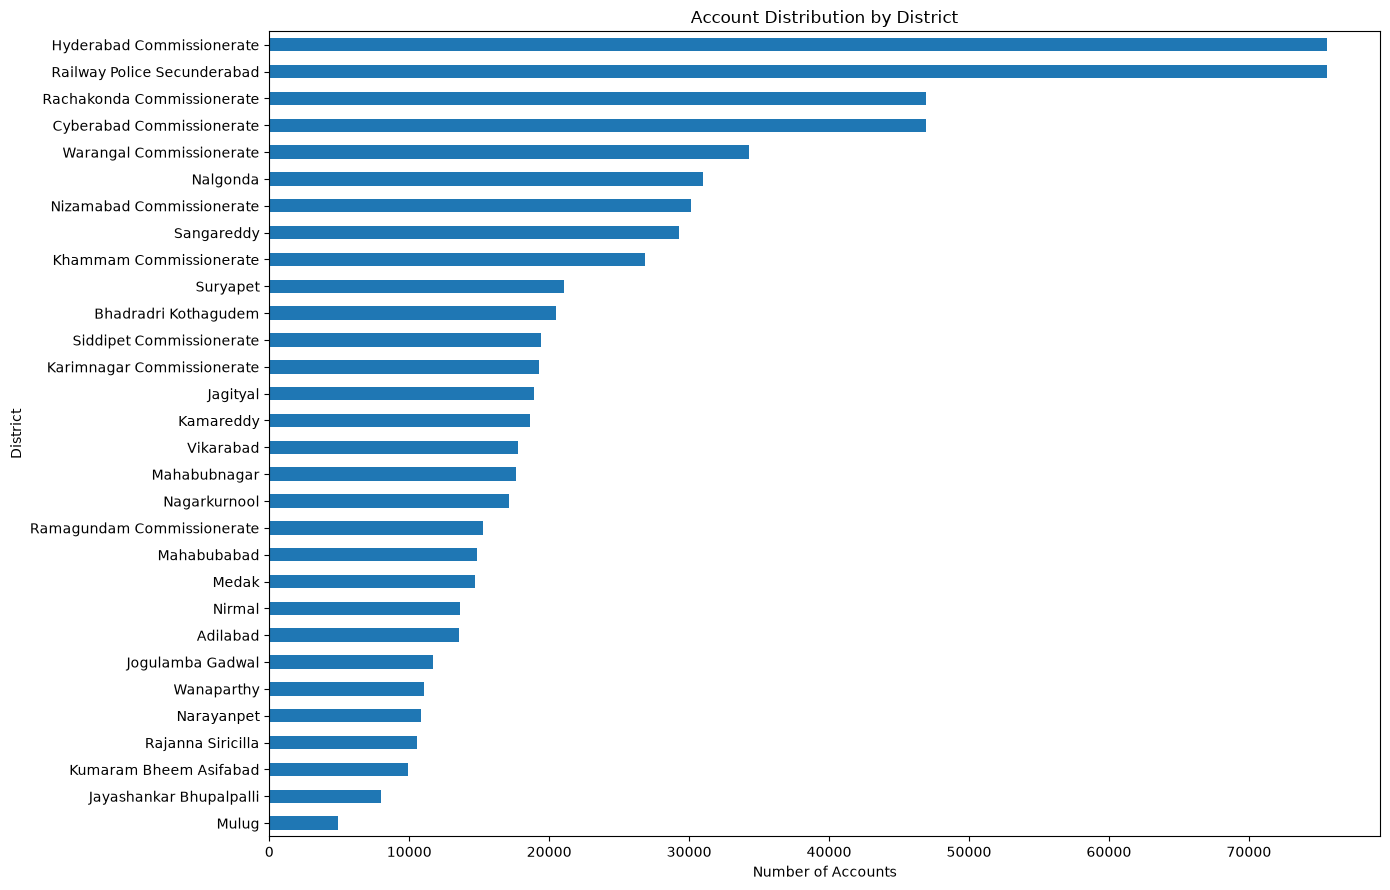

,accounts,population,crime_count,population_share,crime_share,total_transactions,laundering_transactions,actual_account_share,laundering_rate,account_share_error
District,,,,,,,,,,
Hyderabad Commissionerate,75592,3943323.0,4436.0,0.107083,0.289992,1468905.0,809.0,0.107085,0.000551,1.992011e-06
Railway Police Secunderabad,75591,3943323.0,0.0,0.107083,0.000000,1452810.0,541.0,0.107084,0.000372,5.753938e-07
Rachakonda Commissionerate,46894,2446265.0,2192.0,0.066430,0.143296,1034447.0,712.0,0.066431,0.000688,1.280620e-06
Cyberabad Commissionerate,46893,2446265.0,5424.0,0.066430,0.354579,902354.0,792.0,0.066429,0.000878,-1.359976e-07
Warangal Commissionerate,34301,1789395.0,631.0,0.048592,0.041250,646600.0,306.0,0.048591,0.000473,-5.418900e-07
Nalgonda,31024,1618416.0,95.0,0.043949,0.006210,582046.0,221.0,0.043949,0.000380,2.249788e-07
Nizamabad Commissionerate,30115,1571022.0,134.0,0.042662,0.008760,568790.0,223.0,0.042661,0.000392,-4.719568e-07
Sangareddy,29283,1527628.0,286.0,0.041484,0.018696,544503.0,233.0,0.041483,0.000428,-7.113959e-07
Khammam Commissionerate,26868,1401639.0,237.0,0.038062,0.015493,541461.0,284.0,0.038062,0.000525,-5.467612e-07


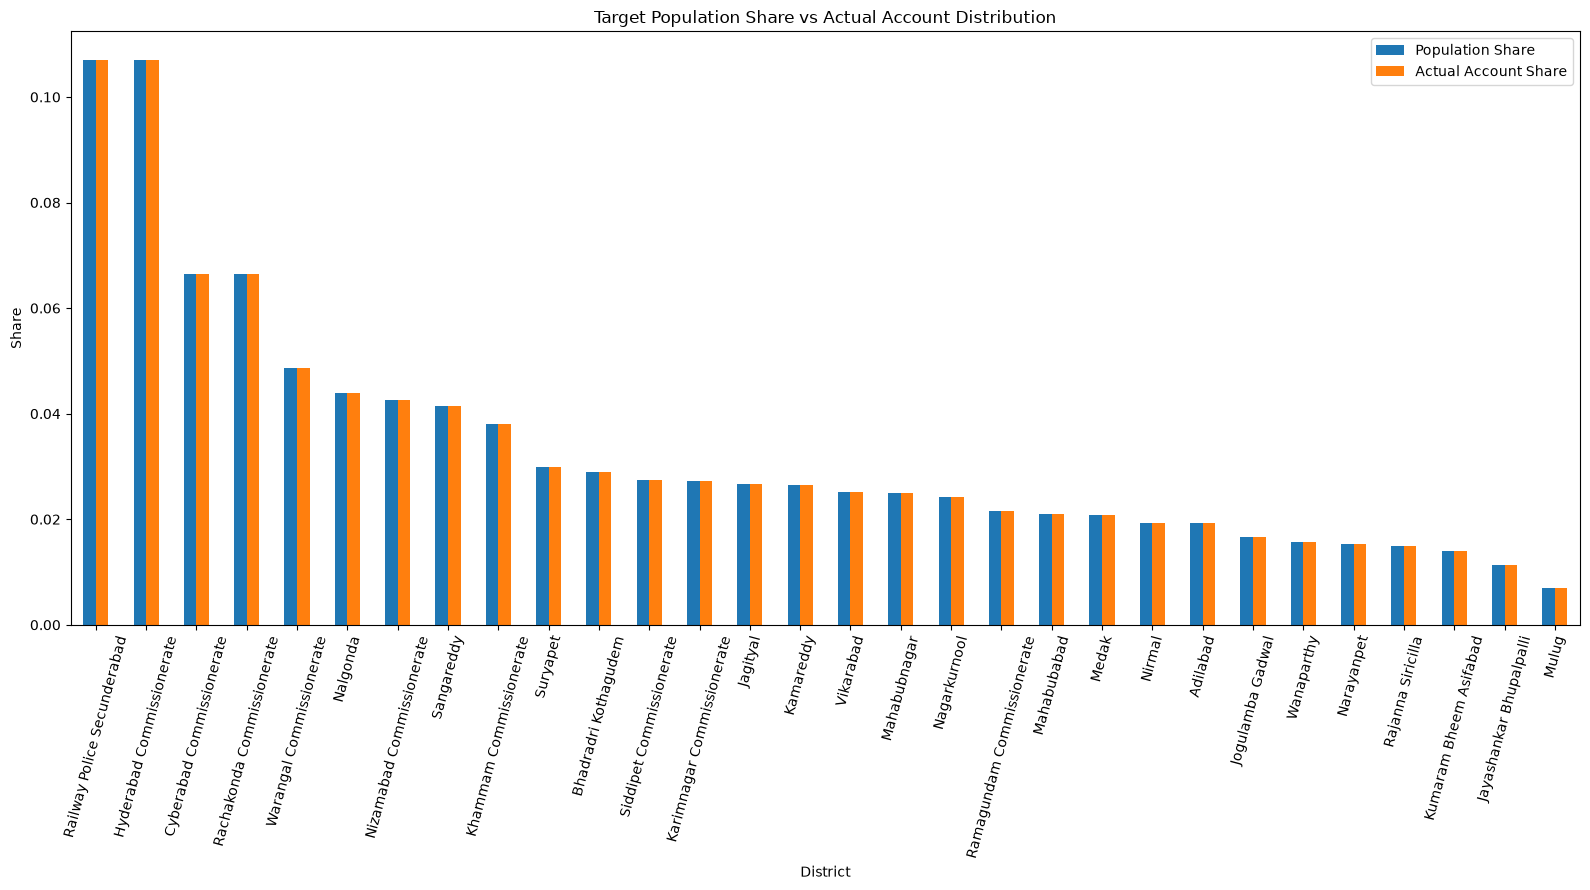

,accounts,laundering_accounts,laundering_transactions,total_transactions,accounts_with_laundering_rate,transaction_laundering_rate
District,,,,,,
Hyderabad Commissionerate,75592,650,809.0,1468905.0,0.008599,0.000551
Cyberabad Commissionerate,46893,619,792.0,902354.0,0.013200,0.000878
Rachakonda Commissionerate,46894,391,712.0,1034447.0,0.008338,0.000688
Railway Police Secunderabad,75591,417,541.0,1452810.0,0.005517,0.000372
Mahabubnagar,17634,108,443.0,557998.0,0.006125,0.000794
Warangal Commissionerate,34301,269,306.0,646600.0,0.007842,0.000473
Khammam Commissionerate,26868,198,284.0,541461.0,0.007369,0.000525
Kamareddy,18644,169,255.0,374600.0,0.009065,0.000681
Sangareddy,29283,195,233.0,544503.0,0.006659,0.000428


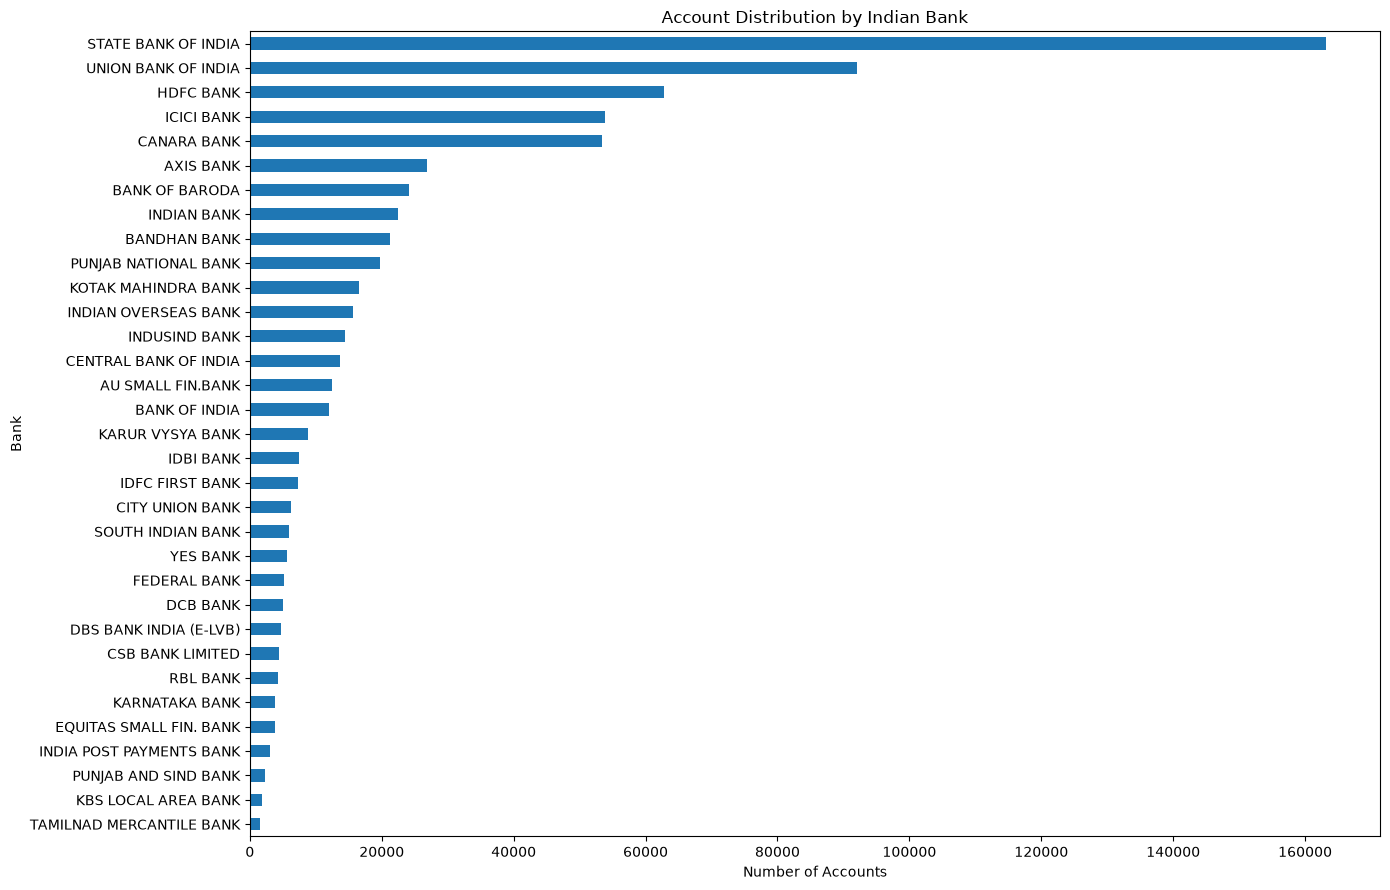

,accounts,branch_weight,target_share,total_transactions,laundering_transactions,actual_share,share_error,laundering_rate
Indian Bank,,,,,,,,
STATE BANK OF INDIA,163193,1215.0,0.231870,3110012.0,1535.0,0.231182,-0.000688,0.000494
UNION BANK OF INDIA,92009,683.0,0.130344,1901344.0,1038.0,0.130342,-0.000002,0.000546
HDFC BANK,62777,465.0,0.088740,1178025.0,626.0,0.088931,0.000191,0.000531
ICICI BANK,53781,398.0,0.075954,997894.0,445.0,0.076187,0.000233,0.000446
CANARA BANK,53386,396.0,0.075573,1250594.0,870.0,0.075628,0.000055,0.000696
AXIS BANK,26903,199.0,0.037977,509200.0,260.0,0.038111,0.000134,0.000511
BANK OF BARODA,24074,178.0,0.033969,452031.0,205.0,0.034104,0.000134,0.000454
INDIAN BANK,22487,167.0,0.031870,421557.0,184.0,0.031855,-0.000015,0.000436
BANDHAN BANK,21242,159.0,0.030344,398192.0,154.0,0.030092,-0.000252,0.000387


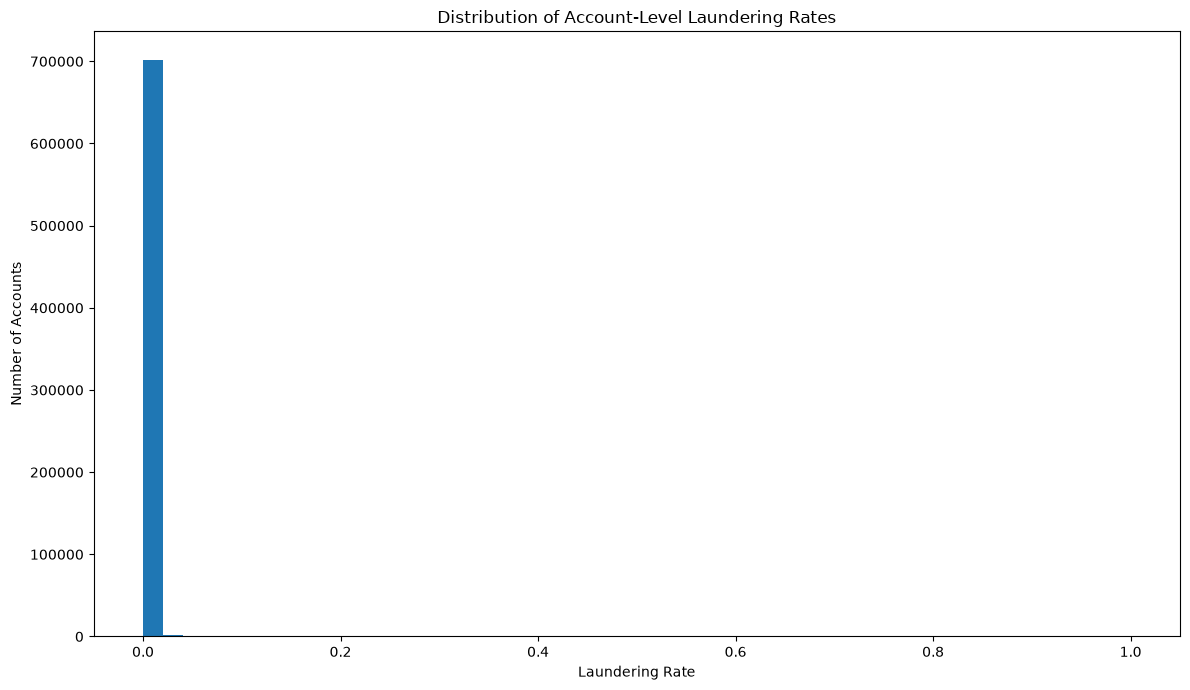


Top accounts by laundering transactions:


,Account Number,District,Indian Bank,total_transactions,laundering_transactions,laundering_rate,total_amount
229793,10042B660,Mahabubnagar,CANARA BANK,223590.0,314.0,0.001404,7.311454e+10
229893,10042B6A8,Rachakonda Commissionerate,UNION BANK OF INDIA,139728.0,196.0,0.001403,3.745186e+10
230011,10042B6F0,Railway Police Secunderabad,CITY UNION BANK,42730.0,48.0,0.001123,1.059057e+11
231053,10042BA08,Khammam Commissionerate,IDFC FIRST BANK,22587.0,39.0,0.001727,2.331919e+10
229483,10042B780,Nirmal,AU SMALL FIN.BANK,31025.0,32.0,0.001031,7.291879e+11
231167,10042BA51,Hyderabad Commissionerate,CANARA BANK,29016.0,31.0,0.001068,7.629145e+05
231674,10042B9C0,Nirmal,INDUSIND BANK,16362.0,29.0,0.001772,2.743786e+10
229376,10042B738,Medak,UNION BANK OF INDIA,18348.0,28.0,0.001526,9.243020e+11
231883,10042B858,Khammam Commissionerate,UNION BANK OF INDIA,15814.0,27.0,0.001707,6.038979e+09
36520,80219F420,Sangareddy,HDFC BANK,65.0,25.0,0.384615,1.077292e+06



Top accounts by laundering rate:


,Account Number,District,Indian Bank,total_transactions,laundering_transactions,laundering_rate,total_amount
693697,8016B3750,Cyberabad Commissionerate,PUNJAB NATIONAL BANK,10.0,8.0,0.800000,86335.49
4539,807F00750,Jagityal,HDFC BANK,8.0,6.0,0.750000,5889158.86
247214,8105AC9A0,Rachakonda Commissionerate,IDFC FIRST BANK,14.0,9.0,0.642857,172702.56
332859,8026B9C00,Adilabad,HDFC BANK,5.0,3.0,0.600000,19835.77
450145,80055C8A0,Warangal Commissionerate,UNION BANK OF INDIA,14.0,8.0,0.571429,162491.77
168223,8005366A0,Mahabubabad,UNION BANK OF INDIA,8.0,4.0,0.500000,37314.17
155040,80011B960,Kamareddy,UNION BANK OF INDIA,39.0,19.0,0.487179,331819.03
80967,800851CF0,Jogulamba Gadwal,STATE BANK OF INDIA,7.0,3.0,0.428571,2135210.64
531520,80045F260,Khammam Commissionerate,HDFC BANK,5.0,2.0,0.400000,8161.58
369577,806103B60,Cyberabad Commissionerate,STATE BANK OF INDIA,5.0,2.0,0.400000,149340.50



DISTRICT CALIBRATION QUALITY


,population_share,actual_account_share,population_error,crime_share,actual_laundering_share,crime_error
District,,,,,,
Cyberabad Commissionerate,0.066430,0.066429,-1.359976e-07,0.354579,0.111080,-0.243499
Hyderabad Commissionerate,0.107083,0.107085,1.992011e-06,0.289992,0.113464,-0.176527
Rachakonda Commissionerate,0.066430,0.066431,1.280620e-06,0.143296,0.099860,-0.043436
Warangal Commissionerate,0.048592,0.048591,-5.418900e-07,0.041250,0.042917,0.001667
Kamareddy,0.026412,0.026411,-7.139294e-07,0.019285,0.035764,0.016480
Sangareddy,0.041484,0.041483,-7.113959e-07,0.018696,0.032679,0.013982
Siddipet Commissionerate,0.027483,0.027482,-7.645227e-07,0.016082,0.024544,0.008463
Khammam Commissionerate,0.038062,0.038062,-5.467612e-07,0.015493,0.039832,0.024338
Jagityal,0.026759,0.026760,4.006562e-07,0.010198,0.027349,0.017151



Mean absolute population-share error: 0.0000%
Mean absolute crime-share error: 3.0898%

District × Indian Bank account matrix:


Indian Bank,AU SMALL FIN.BANK,AXIS BANK,BANDHAN BANK,BANK OF BARODA,BANK OF INDIA,CANARA BANK,CENTRAL BANK OF INDIA,CITY UNION BANK,CSB BANK LIMITED,DBS BANK INDIA (E-LVB),...,KBS LOCAL AREA BANK,KOTAK MAHINDRA BANK,PUNJAB AND SIND BANK,PUNJAB NATIONAL BANK,RBL BANK,SOUTH INDIAN BANK,STATE BANK OF INDIA,TAMILNAD MERCANTILE BANK,UNION BANK OF INDIA,YES BANK
District,,,,,,,,,,,,,,,,,,,,,
Adilabad,240,523,357,464,243,1014,259,127,88,78,...,37,313,37,383,89,151,3127,24,1764,118
Bhadradri Kothagudem,380,739,578,675,344,1571,381,187,134,131,...,64,467,76,550,167,191,4688,47,2637,174
Cyberabad Commissionerate,835,1775,1415,1597,819,3532,863,422,299,284,...,108,1070,155,1305,276,386,10861,123,6096,357
Hyderabad Commissionerate,1346,2934,2231,2631,1247,5665,1498,665,509,526,...,186,1764,282,2124,465,652,17515,167,9773,638
Jagityal,312,700,592,647,317,1383,349,154,113,146,...,48,416,70,522,107,150,4380,33,2512,158
Jayashankar Bhupalpalli,132,277,256,292,130,594,174,72,48,49,...,20,195,25,226,50,62,1869,12,952,56
Jogulamba Gadwal,219,442,350,399,190,866,240,120,61,75,...,25,278,31,292,82,112,2726,24,1538,103
Kamareddy,332,694,560,633,317,1461,370,163,118,125,...,48,441,53,543,112,146,4314,48,2410,136
Karimnagar Commissionerate,334,778,617,650,314,1450,367,162,101,129,...,55,445,63,565,122,160,4426,32,2487,178



SUMMARY
Total accounts: 712688
Accounts with laundering activity: 5304
Total transactions represented: 13848205.0
Total laundering transactions: 7130.0
Overall account-level laundering rate: 0.0515%
Districts: 30
Indian banks: 33


In [ ]:
# ============================================================
# ENRICHED ACCOUNTS — COMPLETE ANALYSIS
# ============================================================

accounts_df = pd.read_csv("enriched_accounts.csv")

print("=" * 70)
print("ENRICHED ACCOUNTS DATASET")
print("=" * 70)

print("\nDataset shape:", accounts_df.shape)

print("\nColumns:")
print(accounts_df.columns.tolist())

print("\nPreview:")
display(accounts_df.head())


# ============================================================
# BASIC STATISTICS
# ============================================================

print("\nBasic statistics:")
display(accounts_df.describe(include="all").T)


# ============================================================
# MISSING VALUES
# ============================================================

print("\nMissing values:")
display(
    accounts_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)


# ============================================================
# DISTRICT — ACCOUNT DISTRIBUTION
# ============================================================

district_accounts = (
    accounts_df["District"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 9))
district_accounts.sort_values().plot(kind="barh")
plt.title("Account Distribution by District")
plt.xlabel("Number of Accounts")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ============================================================
# DISTRICT — POPULATION SHARE VS ACTUAL ACCOUNT SHARE
# ============================================================

district_distribution = (
    accounts_df
    .groupby("District")
    .agg(
        accounts=("Account Number", "count"),
        population=("Population", "first"),
        crime_count=("Crime Count", "first"),
        population_share=("Population Share", "first"),
        crime_share=("Crime Share", "first"),
        total_transactions=("total_transactions", "sum"),
        laundering_transactions=(
            "laundering_transactions",
            "sum"
        )
    )
)

district_distribution["actual_account_share"] = (
    district_distribution["accounts"]
    / district_distribution["accounts"].sum()
)

district_distribution["laundering_rate"] = (
    district_distribution["laundering_transactions"]
    / district_distribution["total_transactions"]
)

district_distribution["account_share_error"] = (
    district_distribution["actual_account_share"]
    - district_distribution["population_share"]
)

display(
    district_distribution.sort_values(
        "accounts",
        ascending=False
    )
)


# ============================================================
# POPULATION SHARE COMPARISON
# ============================================================

comparison = district_distribution[
    [
        "population_share",
        "actual_account_share"
    ]
].sort_values(
    "population_share",
    ascending=False
)

comparison.plot(
    kind="bar",
    figsize=(16, 9)
)

plt.title(
    "Target Population Share vs Actual Account Distribution"
)

plt.xlabel("District")
plt.ylabel("Share")

plt.xticks(rotation=75)
plt.legend(
    [
        "Population Share",
        "Actual Account Share"
    ]
)

plt.tight_layout()
plt.show()


# ============================================================
# ACCOUNT LAUNDERING DISTRIBUTION
# ============================================================

district_laundering_accounts = (
    accounts_df
    .groupby("District")
    .agg(
        accounts=("Account Number", "count"),
        laundering_accounts=(
            "laundering_transactions",
            lambda x: (x > 0).sum()
        ),
        laundering_transactions=(
            "laundering_transactions",
            "sum"
        ),
        total_transactions=(
            "total_transactions",
            "sum"
        )
    )
)

district_laundering_accounts["accounts_with_laundering_rate"] = (
    district_laundering_accounts["laundering_accounts"]
    / district_laundering_accounts["accounts"]
)

district_laundering_accounts["transaction_laundering_rate"] = (
    district_laundering_accounts["laundering_transactions"]
    / district_laundering_accounts["total_transactions"]
)

display(
    district_laundering_accounts
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)


# ============================================================
# BANK — ACCOUNT DISTRIBUTION
# ============================================================

bank_accounts = (
    accounts_df["Indian Bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 9))
bank_accounts.sort_values().plot(kind="barh")
plt.title("Account Distribution by Indian Bank")
plt.xlabel("Number of Accounts")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ============================================================
# BANK — TARGET SHARE VS ACTUAL SHARE
# ============================================================

bank_distribution = (
    accounts_df
    .groupby("Indian Bank")
    .agg(
        accounts=("Account Number", "count"),
        branch_weight=("Branch Weight", "first"),
        target_share=("Bank Share", "first"),
        total_transactions=("total_transactions", "sum"),
        laundering_transactions=(
            "laundering_transactions",
            "sum"
        )
    )
)

bank_distribution["actual_share"] = (
    bank_distribution["accounts"]
    / bank_distribution["accounts"].sum()
)

bank_distribution["share_error"] = (
    bank_distribution["actual_share"]
    - bank_distribution["target_share"]
)

bank_distribution["laundering_rate"] = (
    bank_distribution["laundering_transactions"]
    / bank_distribution["total_transactions"]
)

display(
    bank_distribution.sort_values(
        "accounts",
        ascending=False
    )
)


# ============================================================
# ACCOUNT LAUNDERING RATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

accounts_df["laundering_rate"].plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Account-Level Laundering Rates")
plt.xlabel("Laundering Rate")
plt.ylabel("Number of Accounts")
plt.tight_layout()
plt.show()


# ============================================================
# TOP ACCOUNTS BY LAUNDERING ACTIVITY
# ============================================================

print("\nTop accounts by laundering transactions:")

top_laundering_accounts = (
    accounts_df[
        [
            "Account Number",
            "District",
            "Indian Bank",
            "total_transactions",
            "laundering_transactions",
            "laundering_rate",
            "total_amount"
        ]
    ]
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
    .head(25)
)

display(top_laundering_accounts)


# ============================================================
# TOP ACCOUNTS BY LAUNDERING RATE
# ============================================================

print("\nTop accounts by laundering rate:")

top_rate_accounts = (
    accounts_df[
        [
            "Account Number",
            "District",
            "Indian Bank",
            "total_transactions",
            "laundering_transactions",
            "laundering_rate",
            "total_amount"
        ]
    ]
    .query("total_transactions >= 5")
    .sort_values(
        "laundering_rate",
        ascending=False
    )
    .head(25)
)

display(top_rate_accounts)


# ============================================================
# CRIME / POPULATION CALIBRATION
# ============================================================

calibration = (
    accounts_df
    .groupby("District")
    .agg(
        accounts=("Account Number", "count"),
        population=("Population", "first"),
        crime_count=("Crime Count", "first"),
        population_share=("Population Share", "first"),
        crime_share=("Crime Share", "first"),
        actual_laundering=(
            "laundering_transactions",
            "sum"
        )
    )
)

calibration["actual_account_share"] = (
    calibration["accounts"]
    / calibration["accounts"].sum()
)

calibration["actual_laundering_share"] = (
    calibration["actual_laundering"]
    / calibration["actual_laundering"].sum()
)

calibration["population_error"] = (
    calibration["actual_account_share"]
    - calibration["population_share"]
)

calibration["crime_error"] = (
    calibration["actual_laundering_share"]
    - calibration["crime_share"]
)

print("\nDISTRICT CALIBRATION QUALITY")

display(
    calibration[
        [
            "population_share",
            "actual_account_share",
            "population_error",
            "crime_share",
            "actual_laundering_share",
            "crime_error"
        ]
    ]
    .sort_values(
        "crime_share",
        ascending=False
    )
)


print(
    "\nMean absolute population-share error:",
    f"{calibration['population_error'].abs().mean():.4%}"
)

print(
    "Mean absolute crime-share error:",
    f"{calibration['crime_error'].abs().mean():.4%}"
)


# ============================================================
# DISTRICT × BANK MATRIX
# ============================================================

district_bank_matrix = pd.crosstab(
    accounts_df["District"],
    accounts_df["Indian Bank"]
)

print("\nDistrict × Indian Bank account matrix:")
display(district_bank_matrix)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("Total accounts:", len(accounts_df))
print(
    "Accounts with laundering activity:",
    (accounts_df["laundering_transactions"] > 0).sum()
)

print(
    "Total transactions represented:",
    accounts_df["total_transactions"].sum()
)

print(
    "Total laundering transactions:",
    accounts_df["laundering_transactions"].sum()
)

print(
    "Overall account-level laundering rate:",
    f"{accounts_df['laundering_transactions'].sum() / accounts_df['total_transactions'].sum():.4%}"
)

print(
    "Districts:",
    accounts_df["District"].nunique()
)

print(
    "Indian banks:",
    accounts_df["Indian Bank"].nunique()
)

In [ ]:
# Find transaction rows containing at least one missing value
missing_rows = df2[df2.isna().any(axis=1)].copy()

print(f"Rows with missing data: {len(missing_rows):,}")

# Accounts involved in rows with missing data
account_columns = ["from_account", "to_account"]

accounts_with_missing_rows = pd.unique(
    missing_rows[account_columns].values.ravel()
)
accounts_with_missing_rows = sorted(
    account for account in accounts_with_missing_rows
    if pd.notna(account)
)

print(f"Accounts involved: {len(accounts_with_missing_rows):,}")

# Missing-column summary for each account
account_missing_summary = []

for account in accounts_with_missing_rows:
    account_rows = missing_rows[
        (missing_rows["from_account"] == account) |
        (missing_rows["to_account"] == account)
    ]

    missing_columns = (
        account_rows.isna()
        .sum()
        .loc[lambda x: x > 0]
        .to_dict()
    )

    account_missing_summary.append({
        "account": account,
        "rows_with_missing_data": len(account_rows),
        "missing_columns": missing_columns
    })

account_missing_summary = pd.DataFrame(account_missing_summary)

display(
    account_missing_summary.sort_values(
        "rows_with_missing_data",
        ascending=False
    )
)

# Display all affected transaction rows
display(
    missing_rows.sort_values(
        ["from_account", "to_account"]
    )
)

Rows with missing data: 0
Accounts involved: 0


KeyError: 'rows_with_missing_data'

In [ ]:
# ============================================================
# FILL MISSING DISTRICT + INDIAN BANK IN enriched_accounts.csv
# USING TRANSACTION DATA (df2)
# ============================================================

import pandas as pd
import numpy as np

# Load enriched accounts
accounts_df = pd.read_csv("enriched_accounts.csv")
df2 = pd.read_csv("enriched_transactions.csv")

df2.columns = [
    "timestamp",
    "from_bank",
    "from_account",
    "to_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering",

    # NEW COLUMNS
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

# ------------------------------------------------------------
# 1. Build account -> district/bank mappings from df2
# ------------------------------------------------------------

# Sender account mapping
from_map = df2[
    ["from_account", "from_district", "from_indian_bank"]
].rename(columns={
    "from_account": "Account Number",
    "from_district": "District",
    "from_indian_bank": "Indian Bank"
})

# Receiver account mapping
to_map = df2[
    ["to_account", "to_district", "to_indian_bank"]
].rename(columns={
    "to_account": "Account Number",
    "to_district": "District",
    "to_indian_bank": "Indian Bank"
})

# Combine both sides
account_tx_map = pd.concat(
    [from_map, to_map],
    ignore_index=True
)

# Remove rows where account number is missing
account_tx_map = account_tx_map.dropna(
    subset=["Account Number"]
)

# ------------------------------------------------------------
# 2. Check whether an account has conflicting mappings
# ------------------------------------------------------------

district_conflicts = (
    account_tx_map
    .dropna(subset=["District"])
    .groupby("Account Number")["District"]
    .nunique()
)

bank_conflicts = (
    account_tx_map
    .dropna(subset=["Indian Bank"])
    .groupby("Account Number")["Indian Bank"]
    .nunique()
)

print("Accounts with conflicting district mappings:",
      (district_conflicts > 1).sum())

print("Accounts with conflicting bank mappings:",
      (bank_conflicts > 1).sum())


# ------------------------------------------------------------
# 3. Resolve mappings
#
# If an account appears multiple times, use the most frequent
# district/bank associated with that account.
# ------------------------------------------------------------

district_map = (
    account_tx_map
    .dropna(subset=["District"])
    .groupby("Account Number")["District"]
    .agg(lambda x: x.mode().iloc[0])
)

bank_map = (
    account_tx_map
    .dropna(subset=["Indian Bank"])
    .groupby("Account Number")["Indian Bank"]
    .agg(lambda x: x.mode().iloc[0])
)


# ------------------------------------------------------------
# 4. Fill ONLY missing values in accounts_df
# ------------------------------------------------------------

# Keep original values untouched
missing_district = (
    accounts_df["District"].isna() |
    accounts_df["District"].astype(str).str.strip().isin(["", "nan"])
)

missing_bank = (
    accounts_df["Indian Bank"].isna() |
    accounts_df["Indian Bank"].astype(str).str.strip().isin(["", "nan"])
)

# Map transaction-derived values
district_from_tx = accounts_df["Account Number"].map(district_map)
bank_from_tx = accounts_df["Account Number"].map(bank_map)

# Fill only missing values
accounts_df.loc[missing_district, "District"] = (
    district_from_tx[missing_district]
)

accounts_df.loc[missing_bank, "Indian Bank"] = (
    bank_from_tx[missing_bank]
)


# ------------------------------------------------------------
# 5. Report results
# ------------------------------------------------------------

print("\n========== FILL RESULTS ==========")

print("Rows in accounts:", len(accounts_df))

print(
    "District values filled:",
    missing_district.sum() - accounts_df.loc[missing_district, "District"].isna().sum()
)

print(
    "Indian Bank values filled:",
    missing_bank.sum() - accounts_df.loc[missing_bank, "Indian Bank"].isna().sum()
)

print(
    "District still missing:",
    accounts_df["District"].isna().sum()
)

print(
    "Indian Bank still missing:",
    accounts_df["Indian Bank"].isna().sum()
)


# ------------------------------------------------------------
# 6. Save corrected file
# ------------------------------------------------------------

accounts_df.to_csv(
    "enriched_accounts.csv",
    index=False
)

print("\nSaved corrected file:")
print("enriched_accounts.csv")


# ------------------------------------------------------------
# 7. Show remaining problematic rows
# ------------------------------------------------------------

remaining = accounts_df[
    accounts_df["District"].isna() |
    accounts_df["Indian Bank"].isna()
]

print("\nRemaining rows without district/bank:", len(remaining))

if len(remaining) > 0:
    display(
        remaining[
            [
                "Account Number",
                "Bank Name",
                "Entity Name",
                "District",
                "Indian Bank"
            ]
        ].head(20)
    )

Accounts with conflicting district mappings: 0
Accounts with conflicting bank mappings: 0

========== FILL RESULTS ==========
Rows in accounts: 712688
District values filled: 0
Indian Bank values filled: 0
District still missing: 6781
Indian Bank still missing: 6781

Saved corrected file:
enriched_accounts.csv

Remaining rows without district/bank: 6781


,Account Number,Bank Name,Entity Name,District,Indian Bank
57,81A67F220,Crytpo Bank #16,Corporation #1875,NaN,NaN
179,81994FC80,Crytpo Bank #33,Corporation #13155,NaN,NaN
247,81A469AB0,Crytpo Bank #32,Partnership #19354,NaN,NaN
292,81ADD4F50,Crytpo Bank #48,Partnership #6656,NaN,NaN
404,819FAAFA0,Crytpo Bank #36,Corporation #124,NaN,NaN
505,81BB3A760,Crytpo Bank #13,Corporation #64770,NaN,NaN
518,818DACA70,Saudi Arabia Bank #37,Corporation #10441,NaN,NaN
601,819506AA0,Brazil Bank #17,Partnership #15830,NaN,NaN
975,81A46EBA0,Crytpo Bank #30,Partnership #16744,NaN,NaN
1000,81A381EB0,Crytpo Bank #130,Sole Proprietorship #1929,NaN,NaN


In [ ]:
# ============================================================
# REMOVE ACCOUNTS THAT NEVER APPEAR IN TRANSACTIONS
# ============================================================

# Get all account numbers that appear in transactions
transaction_accounts = set(
    pd.concat([
        df2["from_account"],
        df2["to_account"]
    ])
    .dropna()
    .astype(str)
    .str.strip()
)

# Normalize account numbers in accounts_df
accounts_df["Account Number"] = (
    accounts_df["Account Number"]
    .astype(str)
    .str.strip()
)

# Keep only accounts that appear in at least one transaction
new_accounts = accounts_df[
    accounts_df["Account Number"].isin(transaction_accounts)
].copy()

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Original accounts:", len(accounts_df))
print("Accounts removed:", len(accounts_df) - len(new_accounts))
print("New accounts:", len(new_accounts))

print(
    "Missing District after filtering:",
    new_accounts["District"].isna().sum()
)

print(
    "Missing Indian Bank after filtering:",
    new_accounts["Indian Bank"].isna().sum()
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

new_accounts.to_csv(
    "new_accounts.csv",
    index=False
)

print("\nSaved: new_accounts.csv")

Original accounts: 712688
Accounts removed: 6781
New accounts: 705907
Missing District after filtering: 0
Missing Indian Bank after filtering: 0

Saved: new_accounts.csv


========== PAYMENT MODE SUMMARY ==========


,transactions,total_amount,avg_amount,median_amount,min_amount,max_amount,std_amount,laundering_transactions,laundering_rate,unique_from_accounts,unique_to_accounts,transaction_share
payment_format,,,,,,,,,,,,
Cheque,2503158,1.871716e+13,7477419.96,2000.45,0.01,3.644854e+12,2.430520e+09,459,0.02,231548,303235,36.15
Credit Card,1780389,1.288668e+11,72381.24,1150.98,0.01,3.847743e+08,2.251038e+06,261,0.01,169761,252376,25.71
ACH,796581,5.919178e+12,7430728.96,1981.90,0.00,8.623400e+11,1.312270e+09,2611,0.33,222587,159379,11.50
Cash,655688,4.332097e+12,6606949.23,1818.70,0.01,3.871530e+11,6.580340e+08,124,0.02,84232,116430,9.47
Reinvestment,650458,1.560993e+12,2399836.78,1813.76,0.01,1.942678e+10,7.001610e+07,0,0.00,478888,478888,9.39
Bitcoin,309208,1.429660e+07,46.24,0.07,0.00,8.145309e+05,3.328730e+03,110,0.04,27443,24575,4.47
Wire,228567,1.718790e+12,7519850.53,1016.76,0.00,1.270365e+11,5.226252e+08,0,0.00,40744,45306,3.30



========== TRANSACTION AMOUNT QUANTILES ==========


,P01,P05,P25,P50,P75,P95,P99
payment_format,,,,,,,
ACH,0.61,14.22,253.04,1981.90,15674.09,846480.86,18943995.18
Bitcoin,0.00,0.00,0.01,0.07,0.43,16.96,234.69
Cash,2.50,20.22,233.59,1818.70,25322.73,1628141.78,32448997.67
Cheque,8.83,56.31,363.27,2000.45,15825.07,802551.87,18335074.60
Credit Card,3.24,19.69,186.86,1150.98,7187.77,96574.72,978120.52
Reinvestment,3.50,6.52,21.31,1813.76,44620.18,1980994.44,25984620.82
Wire,0.21,3.81,89.74,1016.76,16932.27,1266858.60,23087455.46


<Figure size 1200x600 with 0 Axes>

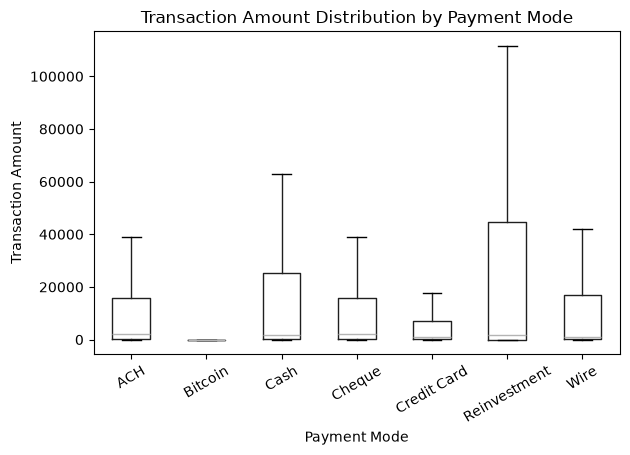

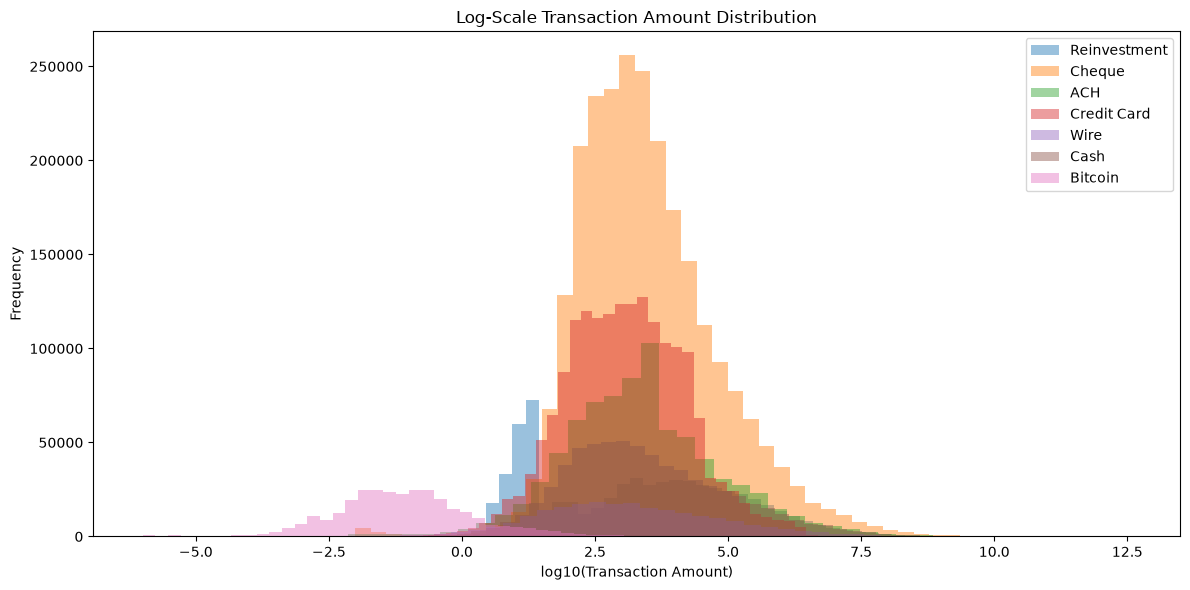


========== TEMPORAL BEHAVIOR ==========


,avg_hour,median_hour,most_common_hour,most_common_day
payment_format,,,,
ACH,11.25,11.0,0,Friday
Bitcoin,10.57,10.0,0,Thursday
Cash,11.33,11.0,0,Friday
Cheque,11.34,11.0,0,Friday
Credit Card,10.18,10.0,0,Friday
Reinvestment,6.11,1.0,0,Thursday
Wire,11.26,11.0,0,Friday



========== LAUNDERING VS NORMAL ==========


,payment_format,is_laundering,transactions,total_amount,avg_amount,median_amount
0,ACH,False,793970,5.908632e+12,7441883.19,1968.24
1,ACH,True,2611,1.054551e+10,4038877.26,4953.29
2,Bitcoin,False,309098,1.428967e+07,46.23,0.07
3,Bitcoin,True,110,6.934040e+03,63.04,0.19
4,Cash,False,655564,4.331819e+12,6607774.16,1818.18
5,Cash,True,124,2.784680e+08,2245709.98,3720.50
6,Cheque,False,2502699,1.871507e+13,7477955.18,2000.29
7,Cheque,True,459,2.092652e+09,4559155.00,3032.95
8,Credit Card,False,1780128,1.288560e+11,72385.80,1150.94
9,Credit Card,True,261,1.077588e+07,41286.88,1285.77



========== ACCOUNT CONCENTRATION ==========


...

,timestamp,payment_format,from_account,to_account,amount_paid,is_laundering,from_district,to_district,from_indian_bank,to_indian_bank
2525880,2022-09-02 23:06:00,Cheque,8018B08B0,8157483D0,3.644854e+12,False,Hyderabad Commissionerate,Nalgonda,AXIS BANK,BANK OF INDIA
3007683,2022-09-04 13:44:00,ACH,80A274810,80A286620,8.623400e+11,False,Railway Police Secunderabad,Rachakonda Commissionerate,ICICI BANK,INDIAN BANK
6883964,2022-09-10 20:14:00,ACH,80ABDDA10,80ABDF080,6.779867e+11,False,Karimnagar Commissionerate,Kamareddy,STATE BANK OF INDIA,UNION BANK OF INDIA
1334434,2022-09-01 19:57:00,Cheque,8068972A0,8145F9B50,6.653123e+11,False,Nagarkurnool,Khammam Commissionerate,INDUSIND BANK,STATE BANK OF INDIA
510834,2022-09-01 01:46:00,Cash,808B7F870,809CE4D70,3.871530e+11,False,Mahabubnagar,Warangal Commissionerate,INDUSIND BANK,INDIAN BANK
...,...,...,...,...,...,...,...,...,...,...
828105,2022-09-01 08:34:00,Bitcoin,8015A12C1,802BDB0B1,4.242352e+05,False,Vikarabad,Wanaparthy,CENTRAL BANK OF INDIA,ICICI BANK
6633922,2022-09-09 23:56:00,Bitcoin,8015A12C1,802BDB0B1,4.242352e+05,False,Vikarabad,Wanaparthy,CENTRAL BANK OF INDIA,ICICI BANK
3717106,2022-09-05 21:30:00,Bitcoin,8015A12C1,802BDB0B1,4.242352e+05,False,Vikarabad,Wanaparthy,CENTRAL BANK OF INDIA,ICICI BANK
1977559,2022-09-02 10:06:00,Bitcoin,8015A12C1,802BDB0B1,4.242352e+05,False,Vikarabad,Wanaparthy,CENTRAL BANK OF INDIA,ICICI BANK



========== TRANSACTION SHARE ==========


,percentage
payment_format,
Cheque,36.15
Credit Card,25.71
ACH,11.50
Cash,9.47
Reinvestment,9.39
Bitcoin,4.47
Wire,3.30



========== FINAL PAYMENT-MODE COMPARISON ==========


,transactions,transaction_share,total_amount,avg_amount,median_amount,min_amount,max_amount,laundering_transactions,laundering_rate,unique_from_accounts,unique_to_accounts
payment_format,,,,,,,,,,,
Cheque,2503158,36.15,1.871716e+13,7477419.96,2000.45,0.01,3.644854e+12,459,0.02,231548,303235
Credit Card,1780389,25.71,1.288668e+11,72381.24,1150.98,0.01,3.847743e+08,261,0.01,169761,252376
ACH,796581,11.50,5.919178e+12,7430728.96,1981.90,0.00,8.623400e+11,2611,0.33,222587,159379
Cash,655688,9.47,4.332097e+12,6606949.23,1818.70,0.01,3.871530e+11,124,0.02,84232,116430
Reinvestment,650458,9.39,1.560993e+12,2399836.78,1813.76,0.01,1.942678e+10,0,0.00,478888,478888
Bitcoin,309208,4.47,1.429660e+07,46.24,0.07,0.00,8.145309e+05,110,0.04,27443,24575
Wire,228567,3.30,1.718790e+12,7519850.53,1016.76,0.00,1.270365e+11,0,0.00,40744,45306


In [ ]:
# ============================================================
# COMPLETE PAYMENT-MODE BEHAVIOR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. OVERALL SUMMARY BY PAYMENT MODE
# ------------------------------------------------------------

mode_summary = (
    df2.groupby("payment_format")
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median"),
        min_amount=("amount_paid", "min"),
        max_amount=("amount_paid", "max"),
        std_amount=("amount_paid", "std"),
        laundering_transactions=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
        unique_from_accounts=("from_account", "nunique"),
        unique_to_accounts=("to_account", "nunique")
    )
    .sort_values("transactions", ascending=False)
)

mode_summary["transaction_share"] = (
    mode_summary["transactions"] /
    mode_summary["transactions"].sum() * 100
)

mode_summary["laundering_rate"] *= 100

print("========== PAYMENT MODE SUMMARY ==========")
display(mode_summary.round(2))


# ------------------------------------------------------------
# 2. TRANSACTION AMOUNT QUANTILES
# ------------------------------------------------------------

amount_stats = (
    df2.groupby("payment_format")["amount_paid"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .unstack()
)

amount_stats.columns = [
    "P01", "P05", "P25", "P50", "P75", "P95", "P99"
]

print("\n========== TRANSACTION AMOUNT QUANTILES ==========")
display(amount_stats.round(2))


# ------------------------------------------------------------
# 3. BOXPLOT OF TRANSACTION AMOUNTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

df2.boxplot(
    column="amount_paid",
    by="payment_format",
    grid=False,
    showfliers=False
)

plt.title("Transaction Amount Distribution by Payment Mode")
plt.suptitle("")
plt.xlabel("Payment Mode")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. LOG-SCALE TRANSACTION AMOUNT DISTRIBUTION
# ------------------------------------------------------------

plot_df = df2[
    df2["amount_paid"].notna() &
    (df2["amount_paid"] > 0)
].copy()

plt.figure(figsize=(12, 6))

for mode in plot_df["payment_format"].dropna().unique():

    values = plot_df.loc[
        plot_df["payment_format"] == mode,
        "amount_paid"
    ]

    plt.hist(
        np.log10(values),
        bins=50,
        alpha=0.45,
        label=mode
    )

plt.title("Log-Scale Transaction Amount Distribution")
plt.xlabel("log10(Transaction Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. TEMPORAL BEHAVIOR
# ------------------------------------------------------------

temporal_df = df2.copy()

temporal_df["hour"] = temporal_df["timestamp"].dt.hour
temporal_df["day_of_week"] = temporal_df["timestamp"].dt.day_name()

temporal_summary = (
    temporal_df
    .groupby("payment_format")
    .agg(
        avg_hour=("hour", "mean"),
        median_hour=("hour", "median"),
        most_common_hour=("hour", lambda x: x.mode().iloc[0]),
        most_common_day=("day_of_week", lambda x: x.mode().iloc[0])
    )
)

print("\n========== TEMPORAL BEHAVIOR ==========")
display(temporal_summary.round(2))


# ------------------------------------------------------------
# 6. LAUNDERING VS NORMAL TRANSACTIONS
# ------------------------------------------------------------

laundering_summary = (
    df2
    .groupby(["payment_format", "is_laundering"])
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median")
    )
    .reset_index()
)

print("\n========== LAUNDERING VS NORMAL ==========")
display(
    laundering_summary
    .sort_values(["payment_format", "is_laundering"])
    .round(2)
)


# ------------------------------------------------------------
# 7. ACCOUNT CONCENTRATION
# ------------------------------------------------------------

account_concentration = (
    df2
    .groupby("payment_format")
    .agg(
        unique_sender_accounts=("from_account", "nunique"),
        unique_receiver_accounts=("to_account", "nunique"),
        transactions=("payment_format", "size")
    )
)

account_concentration["transactions_per_sender"] = (
    account_concentration["transactions"] /
    account_concentration["unique_sender_accounts"]
)

account_concentration["transactions_per_receiver"] = (
    account_concentration["transactions"] /
    account_concentration["unique_receiver_accounts"]
)

print("\n========== ACCOUNT CONCENTRATION ==========")
display(account_concentration.round(2))


# ------------------------------------------------------------
# 8. DISTRICT BEHAVIOR
# ------------------------------------------------------------

district_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_districts=("from_district", "nunique"),
        unique_to_districts=("to_district", "nunique"),
        top_from_district=(
            "from_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_district=(
            "to_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== DISTRICT BEHAVIOR ==========")
display(district_behavior)


# ------------------------------------------------------------
# 9. BANK BEHAVIOR
# ------------------------------------------------------------

bank_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_banks=("from_indian_bank", "nunique"),
        unique_to_banks=("to_indian_bank", "nunique"),
        top_from_bank=(
            "from_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_bank=(
            "to_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== BANK BEHAVIOR ==========")
display(bank_behavior)


# ------------------------------------------------------------
# 10. TOP 10 TRANSACTIONS WITHIN EACH PAYMENT MODE
# ------------------------------------------------------------

top_transactions = (
    df2
    .sort_values("amount_paid", ascending=False)
    .groupby("payment_format")
    .head(10)
    [
        [
            "timestamp",
            "payment_format",
            "from_account",
            "to_account",
            "amount_paid",
            "is_laundering",
            "from_district",
            "to_district",
            "from_indian_bank",
            "to_indian_bank"
        ]
    ]
)

print("\n========== TOP TRANSACTIONS BY PAYMENT MODE ==========")
display(top_transactions)


# ------------------------------------------------------------
# 11. TRANSACTION SHARE
# ------------------------------------------------------------

transaction_share = (
    df2["payment_format"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

print("\n========== TRANSACTION SHARE ==========")
display(transaction_share)


# ------------------------------------------------------------
# 12. FINAL COMBINED TABLE
# ------------------------------------------------------------

final_comparison = mode_summary[
    [
        "transactions",
        "transaction_share",
        "total_amount",
        "avg_amount",
        "median_amount",
        "min_amount",
        "max_amount",
        "laundering_transactions",
        "laundering_rate",
        "unique_from_accounts",
        "unique_to_accounts"
    ]
].copy()

print("\n========== FINAL PAYMENT-MODE COMPARISON ==========")
display(final_comparison.round(2))

In [ ]:
# ============================================================
# CREATE NEW INDIAN-CONTEXT TRANSACTION DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD ENRICHED TRANSACTIONS
# ------------------------------------------------------------

df = pd.read_csv("enriched_transactions.csv")

print("Original shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

df.columns = [
    "timestamp",
    "from_bank",
    "from_account",
    "to_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering",

    # NEW COLUMNS
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

# ------------------------------------------------------------
# 2. MAP IBM PAYMENT MODES TO INDIAN-CONTEXT MODES
# ------------------------------------------------------------

PAYMENT_MODE_MAP = {
    "Cheque": "UPI",
    "Credit Card": "UPI",
    "Reinvestment": "UPI",
    
    "ACH": "IMPS",
    "Wire": "NEFT",
    
    "Cash": "ATM Withdrawal",
    
    "Bitcoin": "Other Digital"
}

df["payment_mode"] = df["payment_format"].map(PAYMENT_MODE_MAP)


# ------------------------------------------------------------
# 3. CHECK FOR UNMAPPED PAYMENT MODES
# ------------------------------------------------------------

unmapped = df.loc[
    df["payment_mode"].isna(),
    "payment_format"
].dropna().unique()

if len(unmapped) > 0:
    print("\nWARNING: Unmapped payment modes:")
    print(unmapped)
else:
    print("\nAll payment modes successfully mapped.")


# ------------------------------------------------------------
# 4. KEEP ONLY REQUIRED COLUMNS
# ------------------------------------------------------------
#
# We keep:
#
# timestamp          -> temporal modelling
# from_account       -> transaction graph
# to_account         -> transaction graph
# amount_paid        -> financial behaviour
# payment_mode       -> Indian-context transaction channel
# is_laundering      -> suspicious/laundering label
# from_district      -> origin geography
# to_district        -> destination geography
# from_indian_bank   -> Indian banking context
# to_indian_bank     -> Indian banking context
#
# We remove:
#
# from_bank / to_bank       -> IBM/US banking identifiers
# receiving_currency        -> unnecessary for INR-focused dataset
# payment_currency          -> unnecessary for INR-focused dataset
# amount_received           -> duplicate financial value for our use
# payment_format            -> replaced by payment_mode
#

required_columns = [
    "timestamp",
    "from_account",
    "to_account",
    "amount_paid",
    "payment_mode",
    "is_laundering",
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]

new_transactions = df[required_columns].copy()


# ------------------------------------------------------------
# 5. CLEAN DATA TYPES
# ------------------------------------------------------------

new_transactions["timestamp"] = pd.to_datetime(
    new_transactions["timestamp"],
    errors="coerce"
)

new_transactions["amount_paid"] = pd.to_numeric(
    new_transactions["amount_paid"],
    errors="coerce"
)

new_transactions["from_account"] = (
    new_transactions["from_account"]
    .astype(str)
    .str.strip()
)

new_transactions["to_account"] = (
    new_transactions["to_account"]
    .astype(str)
    .str.strip()
)

for col in [
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank"
]:
    new_transactions[col] = (
        new_transactions[col]
        .astype(str)
        .str.strip()
        .replace("nan", np.nan)
    )


# ------------------------------------------------------------
# 6. REMOVE INVALID ROWS
# ------------------------------------------------------------

before = len(new_transactions)

new_transactions = new_transactions.dropna(
    subset=[
        "timestamp",
        "from_account",
        "to_account",
        "amount_paid",
        "payment_mode"
    ]
)

new_transactions = new_transactions[
    new_transactions["amount_paid"] >= 0
]

after = len(new_transactions)

print("\nRows removed during cleaning:", before - after)


# ------------------------------------------------------------
# 7. REORDER COLUMNS
# ------------------------------------------------------------

new_transactions = new_transactions[
    [
        "timestamp",
        "from_account",
        "to_account",
        "amount_paid",
        "payment_mode",
        "is_laundering",
        "from_district",
        "to_district",
        "from_indian_bank",
        "to_indian_bank"
    ]
]


# ------------------------------------------------------------
# 8. SAVE
# ------------------------------------------------------------

new_transactions.to_csv(
    "new_transactions.csv",
    index=False
)


# ------------------------------------------------------------
# 9. VALIDATION
# ------------------------------------------------------------

print("\n================================================")
print("NEW TRANSACTION DATASET")
print("================================================")

print("Shape:", new_transactions.shape)

print("\nColumns:")
print(new_transactions.columns.tolist())

print("\nPayment-mode distribution:")
mode_distribution = (
    new_transactions["payment_mode"]
    .value_counts()
    .to_frame("transactions")
)

mode_distribution["percentage"] = (
    mode_distribution["transactions"]
    / len(new_transactions)
    * 100
)

display(mode_distribution.round(2))

print("\nSample:")
display(new_transactions.head())

print("\nMissing values:")
display(new_transactions.isna().sum())

print("\nSaved as:")
print("new_transactions.csv")

Original shape: (6924049, 15)

Original columns:
['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'From District', 'To District', 'From Indian Bank', 'To Indian Bank']

All payment modes successfully mapped.

Rows removed during cleaning: 0

NEW TRANSACTION DATASET
Shape: (6924049, 10)

Columns:
['timestamp', 'from_account', 'to_account', 'amount_paid', 'payment_mode', 'is_laundering', 'from_district', 'to_district', 'from_indian_bank', 'to_indian_bank']

Payment-mode distribution:


,transactions,percentage
payment_mode,,
UPI,4934005,71.26
IMPS,796581,11.50
ATM Withdrawal,655688,9.47
Other Digital,309208,4.47
NEFT,228567,3.30



Sample:


,timestamp,from_account,to_account,amount_paid,payment_mode,is_laundering,from_district,to_district,from_indian_bank,to_indian_bank
0,2022-09-01 00:08:00,8000ECA90,8000ECA90,3195403.00,UPI,False,Jagityal,Jagityal,HDFC BANK,HDFC BANK
1,2022-09-01 00:21:00,80021DAD0,80021DAD0,1858.96,UPI,False,Hyderabad Commissionerate,Hyderabad Commissionerate,HDFC BANK,HDFC BANK
2,2022-09-01 00:00:00,8000ECA90,8006AA910,592571.00,UPI,False,Jagityal,Medak,HDFC BANK,CANARA BANK
3,2022-09-01 00:16:00,8006AD080,8006AD080,12.32,UPI,False,Cyberabad Commissionerate,Cyberabad Commissionerate,UNION BANK OF INDIA,UNION BANK OF INDIA
4,2022-09-01 00:00:00,8006AD530,8006AD530,2941.56,UPI,False,Warangal Commissionerate,Warangal Commissionerate,DBS BANK INDIA (E-LVB),DBS BANK INDIA (E-LVB)



Missing values:


timestamp           0
from_account        0
to_account          0
amount_paid         0
payment_mode        0
is_laundering       0
from_district       0
to_district         0
from_indian_bank    0
to_indian_bank      0
dtype: int64


Saved as:
new_transactions.csv


========== PAYMENT MODE SUMMARY ==========


,transactions,total_amount,avg_amount,median_amount,min_amount,max_amount,std_amount,laundering_transactions,laundering_rate,unique_from_accounts,unique_to_accounts,transaction_share
payment_format,,,,,,,,,,,,
UPI,4934005,2.040702e+13,4135995.69,1622.70,0.01,3.644854e+12,1.731376e+09,720,0.01,596547,538453,71.26
IMPS,796581,5.919178e+12,7430728.96,1981.90,0.00,8.623400e+11,1.312270e+09,2611,0.33,222587,159379,11.50
ATM Withdrawal,655688,4.332097e+12,6606949.23,1818.70,0.01,3.871530e+11,6.580340e+08,124,0.02,84232,116430,9.47
Other Digital,309208,1.429660e+07,46.24,0.07,0.00,8.145309e+05,3.328730e+03,110,0.04,27443,24575,4.47
NEFT,228567,1.718790e+12,7519850.53,1016.76,0.00,1.270365e+11,5.226252e+08,0,0.00,40744,45306,3.30



========== TRANSACTION AMOUNT QUANTILES ==========


,P01,P05,P25,P50,P75,P95,P99
payment_format,,,,,,,
ATM Withdrawal,2.50,20.22,233.59,1818.70,25322.73,1628141.78,32448997.67
IMPS,0.61,14.22,253.04,1981.90,15674.09,846480.86,18943995.18
NEFT,0.21,3.81,89.74,1016.76,16932.27,1266858.60,23087455.46
Other Digital,0.00,0.00,0.01,0.07,0.43,16.96,234.69
UPI,3.97,17.27,239.85,1622.70,12626.67,525422.04,10069435.09


<Figure size 1200x600 with 0 Axes>

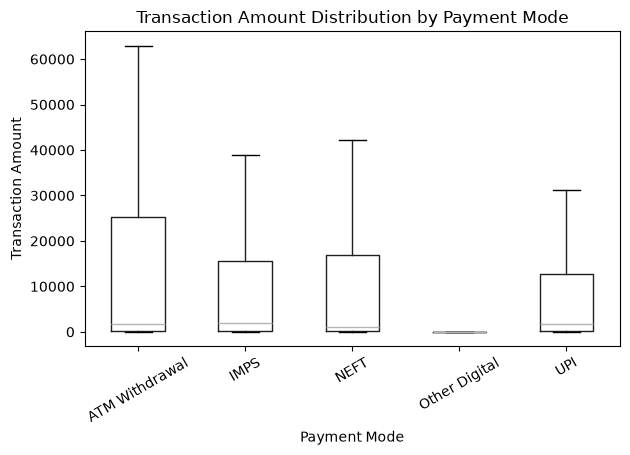

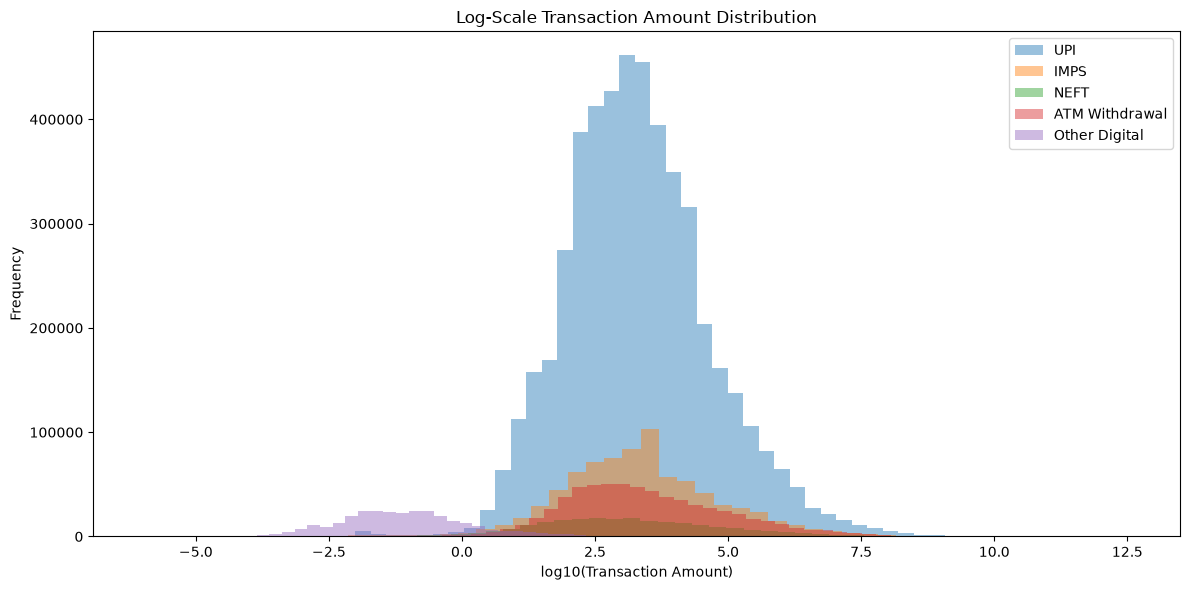


========== TEMPORAL BEHAVIOR ==========


,avg_hour,median_hour,most_common_hour,most_common_day
payment_format,,,,
ATM Withdrawal,11.33,11.0,0,Friday
IMPS,11.25,11.0,0,Friday
NEFT,11.26,11.0,0,Friday
Other Digital,10.57,10.0,0,Thursday
UPI,10.23,10.0,0,Thursday



========== LAUNDERING VS NORMAL ==========


,payment_format,is_laundering,transactions,total_amount,avg_amount,median_amount
0,ATM Withdrawal,False,655564,4.331819e+12,6607774.16,1818.18
1,ATM Withdrawal,True,124,2.784680e+08,2245709.98,3720.50
2,IMPS,False,793970,5.908632e+12,7441883.19,1968.24
3,IMPS,True,2611,1.054551e+10,4038877.26,4953.29
4,NEFT,False,228567,1.718790e+12,7519850.53,1016.76
5,Other Digital,False,309098,1.428967e+07,46.23,0.07
6,Other Digital,True,110,6.934040e+03,63.04,0.19
7,UPI,False,4933285,2.040492e+13,4136172.95,1622.62
8,UPI,True,720,2.103428e+09,2921427.81,2194.00



========== ACCOUNT CONCENTRATION ==========


...

,timestamp,payment_format,from_account,to_account,amount_paid,is_laundering,from_district,to_district,from_indian_bank,to_indian_bank
2525880,2022-09-02 23:06:00,UPI,8018B08B0,8157483D0,3.644854e+12,False,Hyderabad Commissionerate,Nalgonda,AXIS BANK,BANK OF INDIA
3007683,2022-09-04 13:44:00,IMPS,80A274810,80A286620,8.623400e+11,False,Railway Police Secunderabad,Rachakonda Commissionerate,ICICI BANK,INDIAN BANK
6883964,2022-09-10 20:14:00,IMPS,80ABDDA10,80ABDF080,6.779867e+11,False,Karimnagar Commissionerate,Kamareddy,STATE BANK OF INDIA,UNION BANK OF INDIA
1334434,2022-09-01 19:57:00,UPI,8068972A0,8145F9B50,6.653123e+11,False,Nagarkurnool,Khammam Commissionerate,INDUSIND BANK,STATE BANK OF INDIA
510834,2022-09-01 01:46:00,ATM Withdrawal,808B7F870,809CE4D70,3.871530e+11,False,Mahabubnagar,Warangal Commissionerate,INDUSIND BANK,INDIAN BANK
303970,2022-09-01 00:21:00,UPI,8059B4BB0,805C0EF50,3.224075e+11,False,Rachakonda Commissionerate,Railway Police Secunderabad,HDFC BANK,KARUR VYSYA BANK
2546433,2022-09-02 23:59:00,UPI,80170F9F0,80828EFD0,3.017955e+11,False,Medak,Nalgonda,HDFC BANK,HDFC BANK
328620,2022-09-01 00:18:00,UPI,8087B2620,80A1E95E0,2.727669e+11,False,Railway Police Secunderabad,Kamareddy,UNION BANK OF INDIA,PUNJAB NATIONAL BANK
464081,2022-09-01 00:30:00,ATM Withdrawal,10042B738,807A63750,2.672622e+11,False,Medak,Nalgonda,UNION BANK OF INDIA,HDFC BANK
5559124,2022-09-08 16:56:00,UPI,800FB0470,8080861F0,2.441316e+11,False,Jogulamba Gadwal,Nizamabad Commissionerate,SOUTH INDIAN BANK,RBL BANK



========== TRANSACTION SHARE ==========


,percentage
payment_format,
UPI,71.26
IMPS,11.50
ATM Withdrawal,9.47
Other Digital,4.47
NEFT,3.30



========== FINAL PAYMENT-MODE COMPARISON ==========


,transactions,transaction_share,total_amount,avg_amount,median_amount,min_amount,max_amount,laundering_transactions,laundering_rate,unique_from_accounts,unique_to_accounts
payment_format,,,,,,,,,,,
UPI,4934005,71.26,2.040702e+13,4135995.69,1622.70,0.01,3.644854e+12,720,0.01,596547,538453
IMPS,796581,11.50,5.919178e+12,7430728.96,1981.90,0.00,8.623400e+11,2611,0.33,222587,159379
ATM Withdrawal,655688,9.47,4.332097e+12,6606949.23,1818.70,0.01,3.871530e+11,124,0.02,84232,116430
Other Digital,309208,4.47,1.429660e+07,46.24,0.07,0.00,8.145309e+05,110,0.04,27443,24575
NEFT,228567,3.30,1.718790e+12,7519850.53,1016.76,0.00,1.270365e+11,0,0.00,40744,45306


In [ ]:
# ============================================================
# COMPLETE PAYMENT-MODE BEHAVIOR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. OVERALL SUMMARY BY PAYMENT MODE
# ------------------------------------------------------------
df2 = pd.read_csv("new_transactions.csv")
df2["payment_format"] = df2["payment_mode"]
df2["timestamp"] = pd.to_datetime(
    df2["timestamp"],
    # format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)
mode_summary = (
    df2.groupby("payment_format")
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median"),
        min_amount=("amount_paid", "min"),
        max_amount=("amount_paid", "max"),
        std_amount=("amount_paid", "std"),
        laundering_transactions=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
        unique_from_accounts=("from_account", "nunique"),
        unique_to_accounts=("to_account", "nunique")
    )
    .sort_values("transactions", ascending=False)
)

mode_summary["transaction_share"] = (
    mode_summary["transactions"] /
    mode_summary["transactions"].sum() * 100
)

mode_summary["laundering_rate"] *= 100

print("========== PAYMENT MODE SUMMARY ==========")
display(mode_summary.round(2))


# ------------------------------------------------------------
# 2. TRANSACTION AMOUNT QUANTILES
# ------------------------------------------------------------

amount_stats = (
    df2.groupby("payment_format")["amount_paid"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .unstack()
)

amount_stats.columns = [
    "P01", "P05", "P25", "P50", "P75", "P95", "P99"
]

print("\n========== TRANSACTION AMOUNT QUANTILES ==========")
display(amount_stats.round(2))


# ------------------------------------------------------------
# 3. BOXPLOT OF TRANSACTION AMOUNTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

df2.boxplot(
    column="amount_paid",
    by="payment_format",
    grid=False,
    showfliers=False
)

plt.title("Transaction Amount Distribution by Payment Mode")
plt.suptitle("")
plt.xlabel("Payment Mode")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. LOG-SCALE TRANSACTION AMOUNT DISTRIBUTION
# ------------------------------------------------------------

plot_df = df2[
    df2["amount_paid"].notna() &
    (df2["amount_paid"] > 0)
].copy()

plt.figure(figsize=(12, 6))

for mode in plot_df["payment_format"].dropna().unique():

    values = plot_df.loc[
        plot_df["payment_format"] == mode,
        "amount_paid"
    ]

    plt.hist(
        np.log10(values),
        bins=50,
        alpha=0.45,
        label=mode
    )

plt.title("Log-Scale Transaction Amount Distribution")
plt.xlabel("log10(Transaction Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. TEMPORAL BEHAVIOR
# ------------------------------------------------------------

temporal_df = df2.copy()

temporal_df["hour"] = temporal_df["timestamp"].dt.hour
temporal_df["day_of_week"] = temporal_df["timestamp"].dt.day_name()

temporal_summary = (
    temporal_df
    .groupby("payment_format")
    .agg(
        avg_hour=("hour", "mean"),
        median_hour=("hour", "median"),
        most_common_hour=("hour", lambda x: x.mode().iloc[0]),
        most_common_day=("day_of_week", lambda x: x.mode().iloc[0])
    )
)

print("\n========== TEMPORAL BEHAVIOR ==========")
display(temporal_summary.round(2))


# ------------------------------------------------------------
# 6. LAUNDERING VS NORMAL TRANSACTIONS
# ------------------------------------------------------------

laundering_summary = (
    df2
    .groupby(["payment_format", "is_laundering"])
    .agg(
        transactions=("payment_format", "size"),
        total_amount=("amount_paid", "sum"),
        avg_amount=("amount_paid", "mean"),
        median_amount=("amount_paid", "median")
    )
    .reset_index()
)

print("\n========== LAUNDERING VS NORMAL ==========")
display(
    laundering_summary
    .sort_values(["payment_format", "is_laundering"])
    .round(2)
)


# ------------------------------------------------------------
# 7. ACCOUNT CONCENTRATION
# ------------------------------------------------------------

account_concentration = (
    df2
    .groupby("payment_format")
    .agg(
        unique_sender_accounts=("from_account", "nunique"),
        unique_receiver_accounts=("to_account", "nunique"),
        transactions=("payment_format", "size")
    )
)

account_concentration["transactions_per_sender"] = (
    account_concentration["transactions"] /
    account_concentration["unique_sender_accounts"]
)

account_concentration["transactions_per_receiver"] = (
    account_concentration["transactions"] /
    account_concentration["unique_receiver_accounts"]
)

print("\n========== ACCOUNT CONCENTRATION ==========")
display(account_concentration.round(2))


# ------------------------------------------------------------
# 8. DISTRICT BEHAVIOR
# ------------------------------------------------------------

district_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_districts=("from_district", "nunique"),
        unique_to_districts=("to_district", "nunique"),
        top_from_district=(
            "from_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_district=(
            "to_district",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== DISTRICT BEHAVIOR ==========")
display(district_behavior)


# ------------------------------------------------------------
# 9. BANK BEHAVIOR
# ------------------------------------------------------------

bank_behavior = (
    df2
    .groupby("payment_format")
    .agg(
        unique_from_banks=("from_indian_bank", "nunique"),
        unique_to_banks=("to_indian_bank", "nunique"),
        top_from_bank=(
            "from_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ),
        top_to_bank=(
            "to_indian_bank",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
)

print("\n========== BANK BEHAVIOR ==========")
display(bank_behavior)


# ------------------------------------------------------------
# 10. TOP 10 TRANSACTIONS WITHIN EACH PAYMENT MODE
# ------------------------------------------------------------

top_transactions = (
    df2
    .sort_values("amount_paid", ascending=False)
    .groupby("payment_format")
    .head(10)
    [
        [
            "timestamp",
            "payment_format",
            "from_account",
            "to_account",
            "amount_paid",
            "is_laundering",
            "from_district",
            "to_district",
            "from_indian_bank",
            "to_indian_bank"
        ]
    ]
)

print("\n========== TOP TRANSACTIONS BY PAYMENT MODE ==========")
display(top_transactions)


# ------------------------------------------------------------
# 11. TRANSACTION SHARE
# ------------------------------------------------------------

transaction_share = (
    df2["payment_format"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

print("\n========== TRANSACTION SHARE ==========")
display(transaction_share)


# ------------------------------------------------------------
# 12. FINAL COMBINED TABLE
# ------------------------------------------------------------

final_comparison = mode_summary[
    [
        "transactions",
        "transaction_share",
        "total_amount",
        "avg_amount",
        "median_amount",
        "min_amount",
        "max_amount",
        "laundering_transactions",
        "laundering_rate",
        "unique_from_accounts",
        "unique_to_accounts"
    ]
].copy()

print("\n========== FINAL PAYMENT-MODE COMPARISON ==========")
display(final_comparison.round(2))

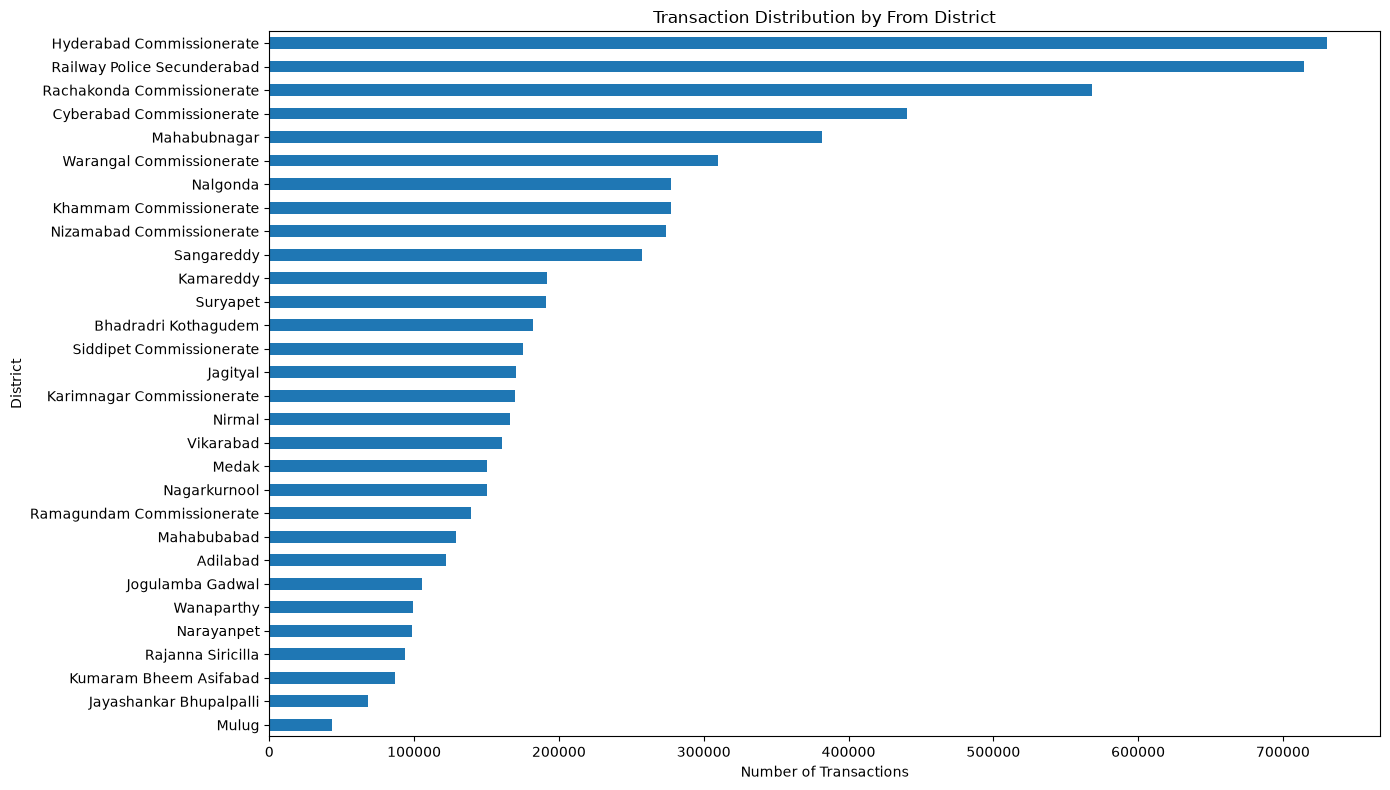

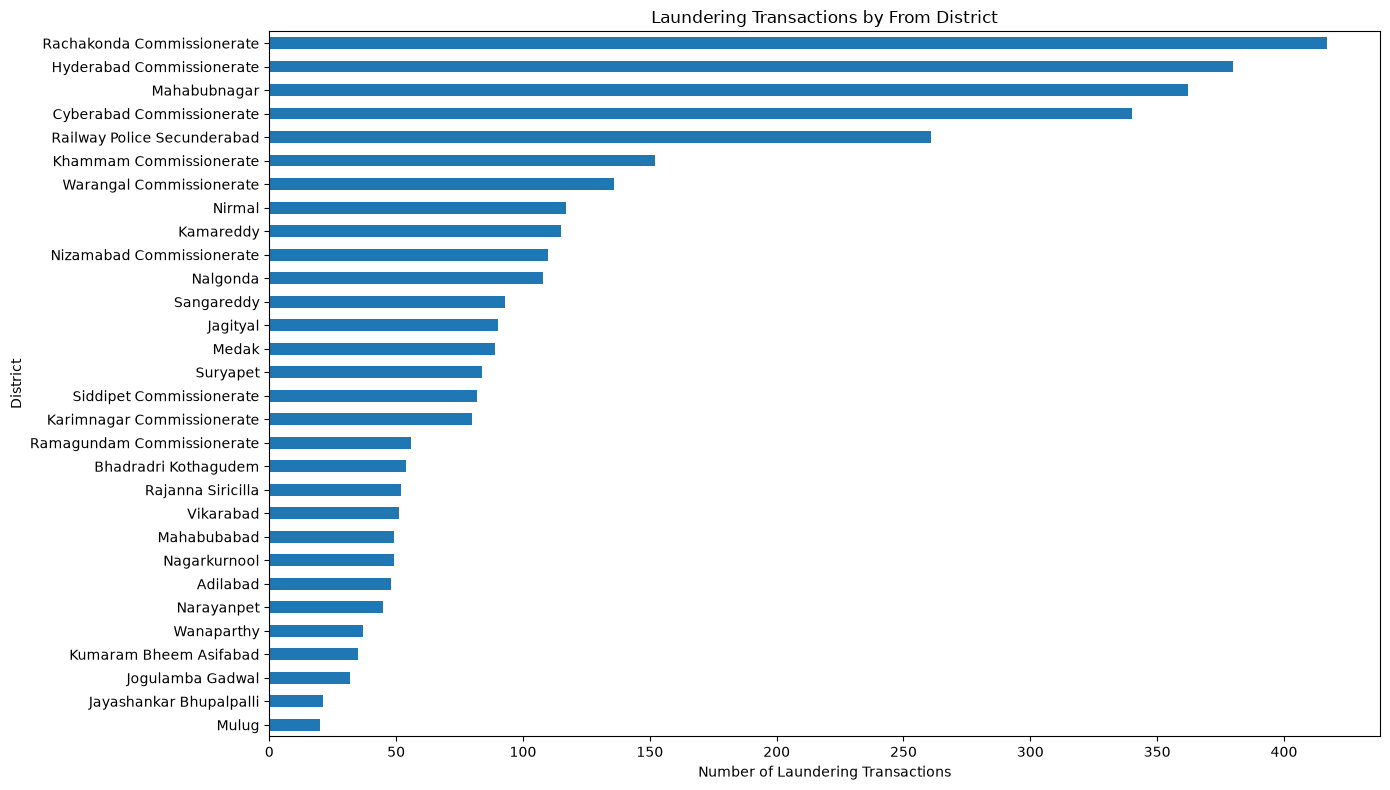

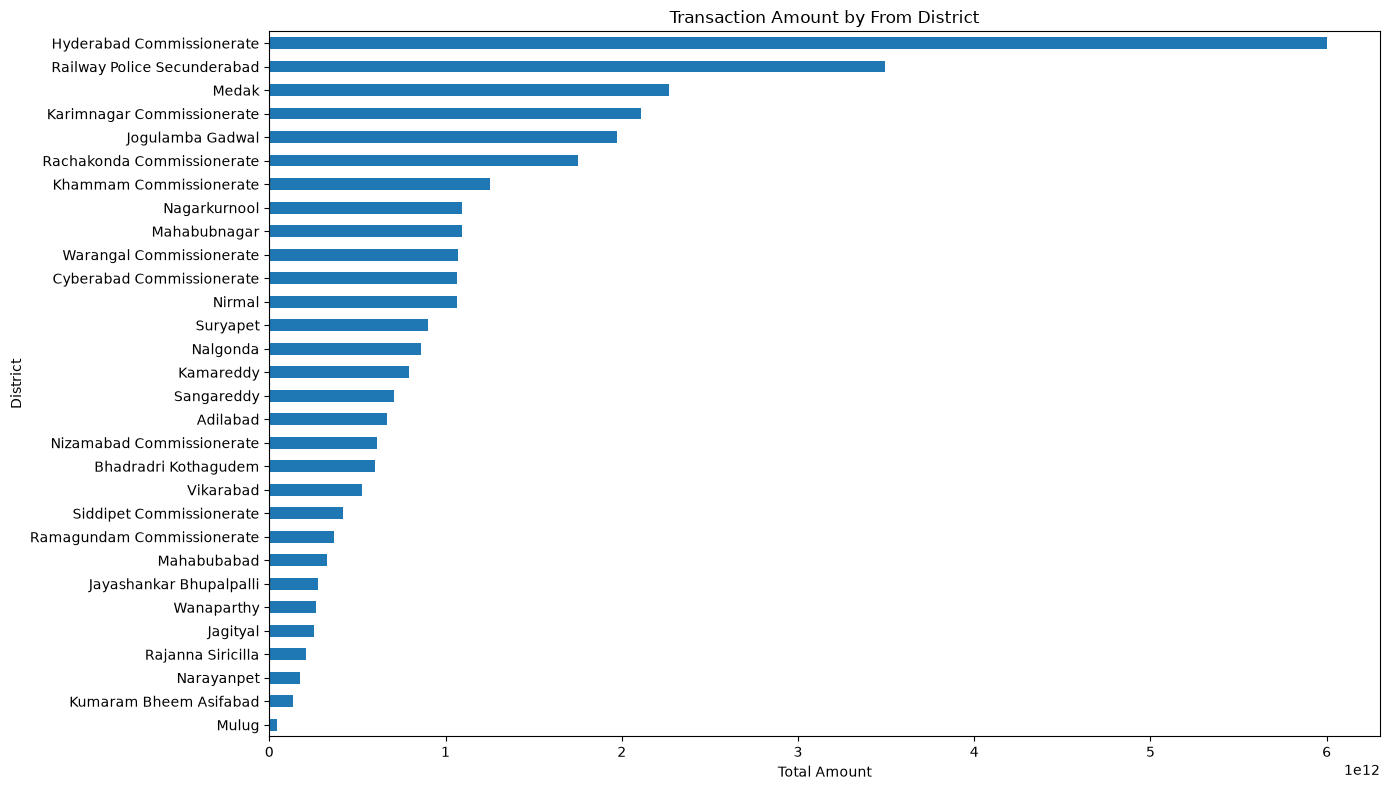

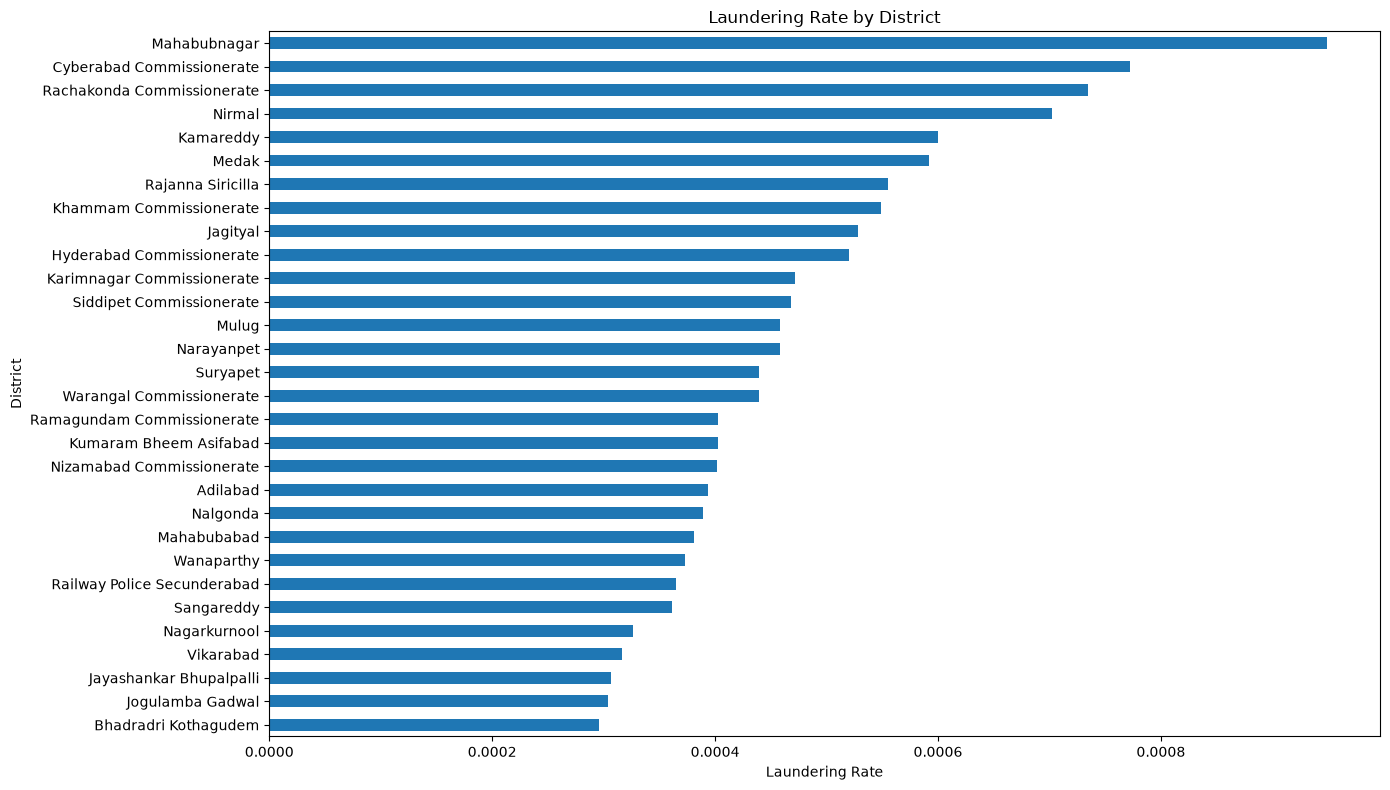

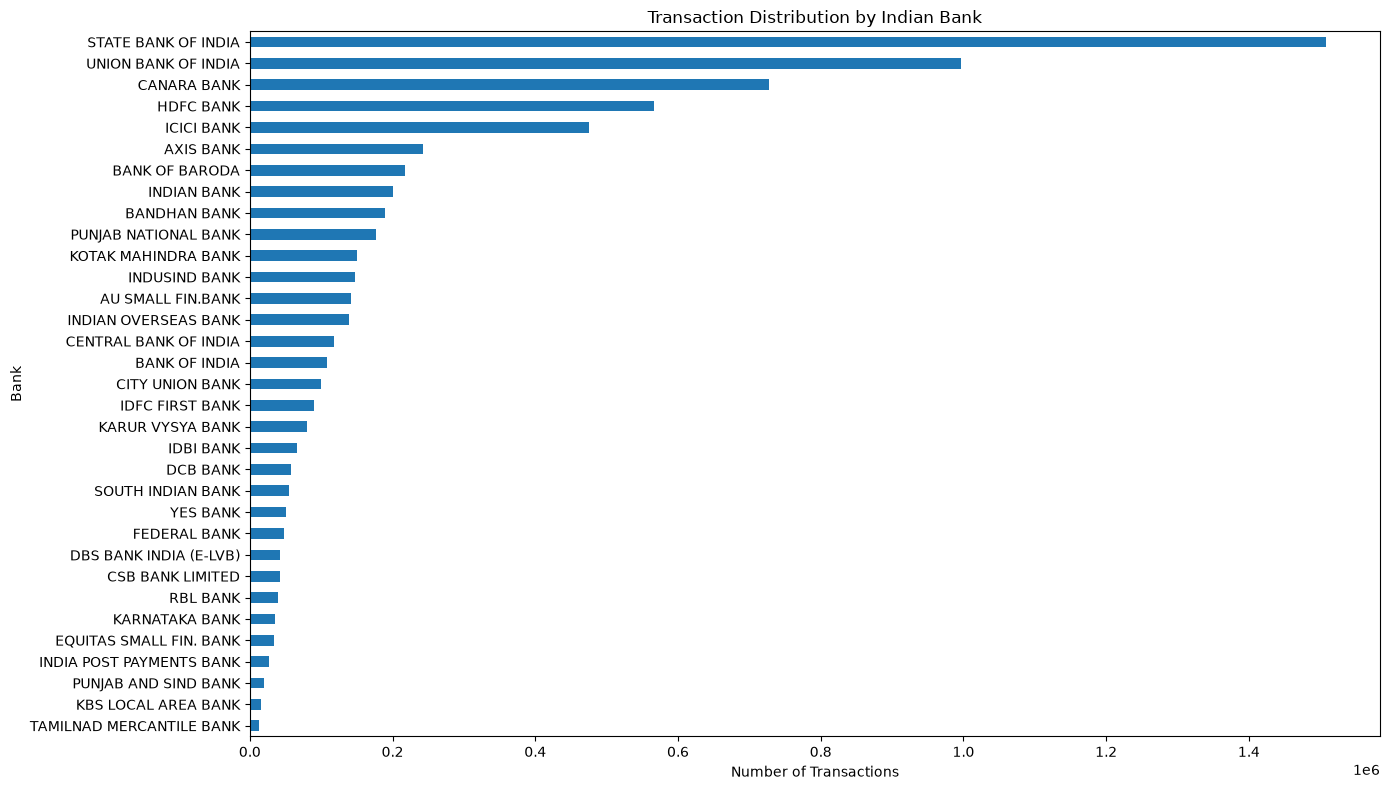

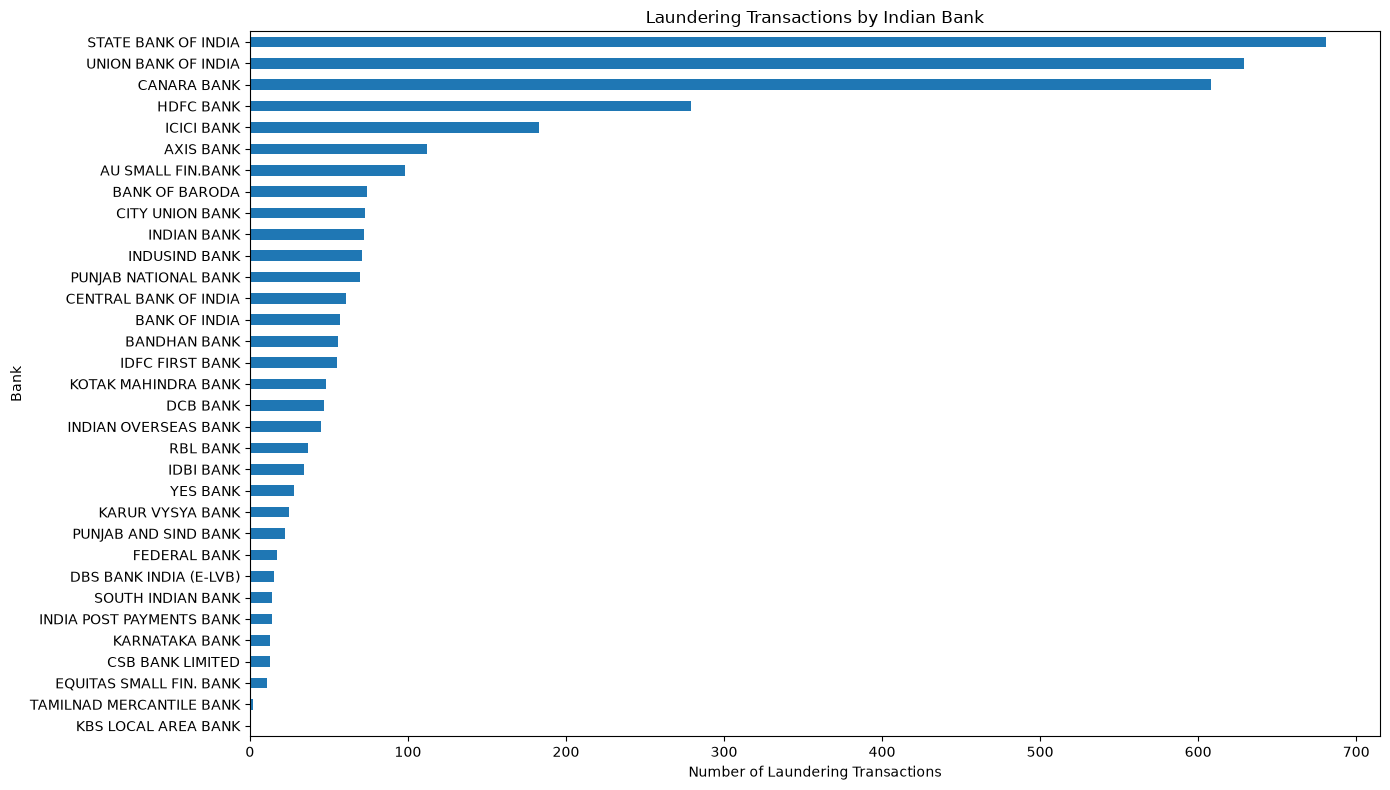

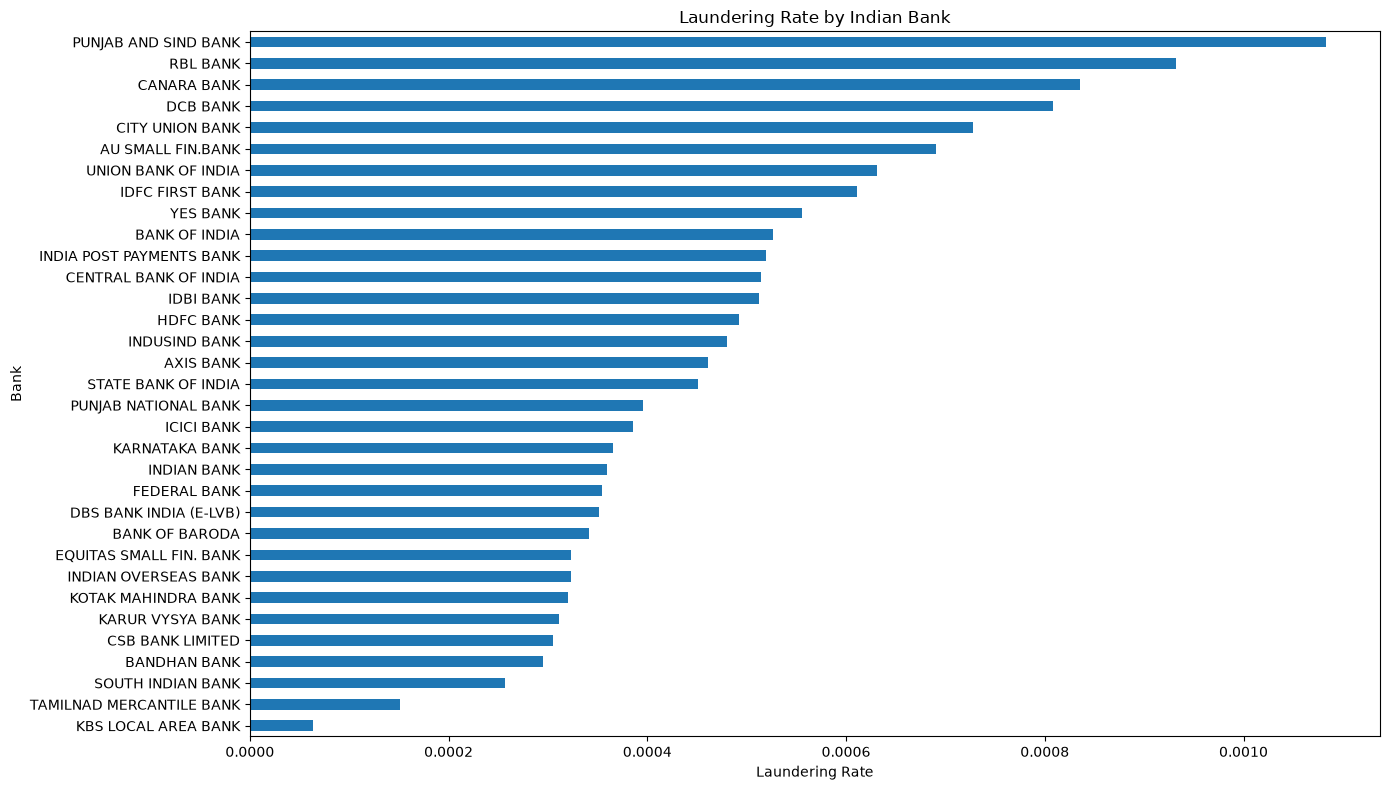

<Figure size 1600x1000 with 0 Axes>

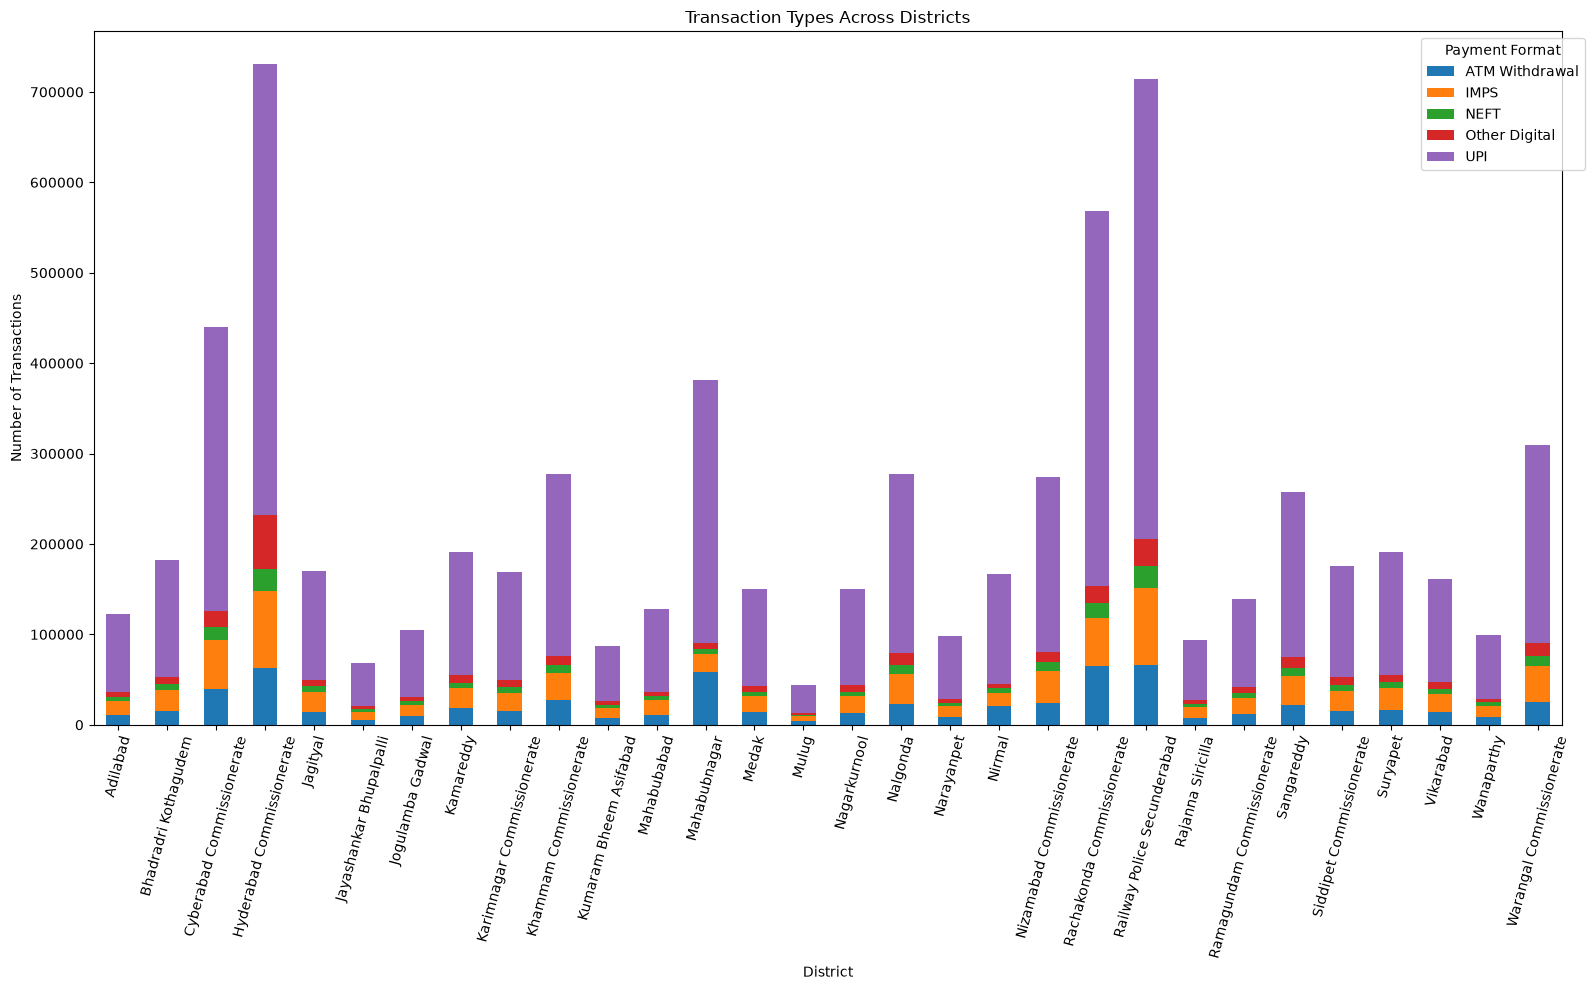

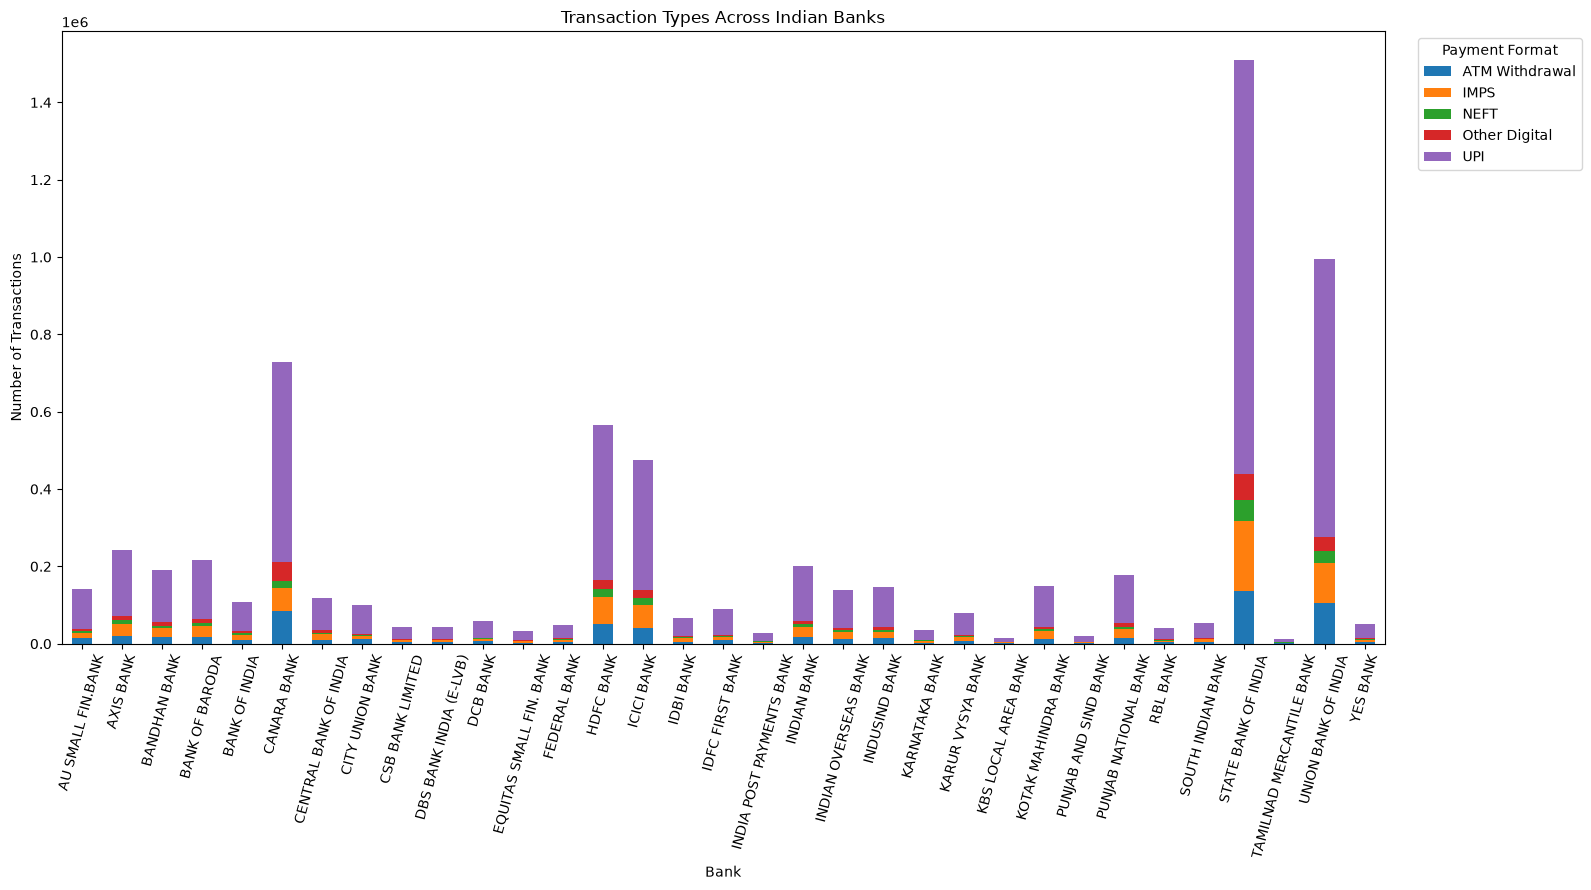

is_laundering,Legitimate,Laundering
from_district,,
Rachakonda Commissionerate,567498,417
Hyderabad Commissionerate,730131,380
Mahabubnagar,381039,362
Cyberabad Commissionerate,439777,340
Railway Police Secunderabad,714530,261
Khammam Commissionerate,276955,152
Warangal Commissionerate,309616,136
Nirmal,166412,117
Kamareddy,191433,115


is_laundering,Legitimate,Laundering
from_indian_bank,,
STATE BANK OF INDIA,1507669,681
UNION BANK OF INDIA,995410,629
CANARA BANK,726712,608
HDFC BANK,565904,279
ICICI BANK,474807,183
AXIS BANK,242585,112
AU SMALL FIN.BANK,141780,98
BANK OF BARODA,216751,74
CITY UNION BANK,100270,73


District-to-district transaction matrix:


to_district,Adilabad,Bhadradri Kothagudem,Cyberabad Commissionerate,Hyderabad Commissionerate,Jagityal,Jayashankar Bhupalpalli,Jogulamba Gadwal,Kamareddy,Karimnagar Commissionerate,Khammam Commissionerate,...,Rachakonda Commissionerate,Railway Police Secunderabad,Rajanna Siricilla,Ramagundam Commissionerate,Sangareddy,Siddipet Commissionerate,Suryapet,Vikarabad,Wanaparthy,Warangal Commissionerate
from_district,,,,,,,,,,,,,,,,,,,,,
Adilabad,17884,3065,6636,11044,3256,1297,1799,2613,3209,3919,...,6821,11812,1715,2112,4563,3118,3460,2301,2065,5385
Bhadradri Kothagudem,3107,27825,10955,16209,4259,1737,2630,4040,4341,5828,...,10857,16590,2615,3115,7152,4960,4810,4118,2345,7271
Cyberabad Commissionerate,7669,11055,78634,42100,10093,4327,6740,10438,10104,14937,...,26719,41179,5840,8234,15182,10310,11397,9984,6344,18260
Hyderabad Commissionerate,12757,18792,42056,154066,16631,7619,10960,17060,17524,24753,...,43604,69525,9659,14249,26740,17578,18804,16566,9812,30787
Jagityal,2881,4478,9764,15463,25926,1602,2634,3876,3993,5512,...,10205,15852,2063,3104,5764,4281,5035,3442,2611,7312
Jayashankar Bhupalpalli,1041,1601,3695,5887,1796,9846,966,1389,1478,2337,...,4202,6343,838,1565,2619,1781,1643,1617,582,2820
Jogulamba Gadwal,1892,2361,6736,9400,2566,1156,14746,2564,2690,3182,...,6019,10158,1143,2153,3701,2482,2850,2426,1260,4787
Kamareddy,2898,5318,10985,18054,4261,2150,2735,26386,4692,6563,...,11381,17415,2582,3118,7598,4923,5148,4242,2604,8377
Karimnagar Commissionerate,2537,4528,9518,15821,3799,1972,2298,4321,25637,5612,...,9936,16607,2081,3221,6077,4293,4487,3477,2102,6887


Top 25 district-to-district flows:


...

,from_indian_bank,to_indian_bank,transactions
986,STATE BANK OF INDIA,STATE BANK OF INDIA,490840
1054,UNION BANK OF INDIA,UNION BANK OF INDIA,221656
1052,UNION BANK OF INDIA,STATE BANK OF INDIA,204023
988,STATE BANK OF INDIA,UNION BANK OF INDIA,173980
194,CANARA BANK,STATE BANK OF INDIA,155608
970,STATE BANK OF INDIA,HDFC BANK,116459
442,HDFC BANK,HDFC BANK,114779
458,HDFC BANK,STATE BANK OF INDIA,113498
170,CANARA BANK,CANARA BANK,110896
962,STATE BANK OF INDIA,CANARA BANK,99670



DISTRICT SUMMARY


,transactions,total_amount,laundering_transactions,unique_accounts,unique_banks,laundering_rate
from_district,,,,,,
Rachakonda Commissionerate,567915,1.752679e+12,417,45207,33,0.000734
Hyderabad Commissionerate,730511,6.002318e+12,380,73058,33,0.000520
Mahabubnagar,381401,1.091732e+12,362,16977,33,0.000949
Cyberabad Commissionerate,440117,1.065452e+12,340,45233,33,0.000773
Railway Police Secunderabad,714791,3.494669e+12,261,72990,33,0.000365
Khammam Commissionerate,277107,1.253733e+12,152,25925,33,0.000549
Warangal Commissionerate,309752,1.072578e+12,136,33118,33,0.000439
Nirmal,166529,1.063798e+12,117,13143,33,0.000703
Kamareddy,191548,7.922346e+11,115,18042,33,0.000600



BANK SUMMARY


,transactions,total_amount,laundering_transactions,unique_accounts,unique_districts,laundering_rate
from_indian_bank,,,,,,
STATE BANK OF INDIA,1508350,7.457540e+12,681,157439,30,0.000451
UNION BANK OF INDIA,996039,2.904723e+12,629,88846,30,0.000632
CANARA BANK,727320,1.501941e+12,608,51522,30,0.000836
HDFC BANK,566183,2.546210e+12,279,60510,30,0.000493
ICICI BANK,474990,2.216129e+12,183,51876,30,0.000385
AXIS BANK,242697,4.245389e+12,112,26036,30,0.000461
AU SMALL FIN.BANK,141878,1.046824e+12,98,12024,30,0.000691
BANK OF BARODA,216825,5.217041e+11,74,23239,30,0.000341
CITY UNION BANK,100343,2.560187e+11,73,6075,30,0.000728


In [ ]:
# ============================================================
# TRANSACTION-LEVEL DISTRICT & BANK ANALYSIS
# Uses existing df2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DISTRICT DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

from_district_counts = (
    df2["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
from_district_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by From District")
plt.xlabel("Number of Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. DISTRICT DISTRIBUTION — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

district_laundering = (
    df2[df2["is_laundering"]]
    ["from_district"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by From District")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. DISTRICT — TOTAL AMOUNT
# ------------------------------------------------------------

district_amount = (
    df2.groupby("from_district")["amount_paid"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
district_amount.sort_values().plot(kind="barh")
plt.title("Transaction Amount by From District")
plt.xlabel("Total Amount")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. DISTRICT — LAUNDERING RATE
# ------------------------------------------------------------

district_stats = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_paid", "sum"),
        laundering_amount=(
            "amount_paid",
            lambda x: x[df2.loc[x.index, "is_laundering"]].sum()
        )
    )
)

district_stats["laundering_rate"] = (
    district_stats["laundering_transactions"]
    / district_stats["transactions"]
)

district_stats = district_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
district_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by District")
plt.xlabel("Laundering Rate")
plt.ylabel("District")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. BANK DISTRIBUTION — TRANSACTION COUNT
# ------------------------------------------------------------

bank_counts = (
    df2["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_counts.sort_values().plot(kind="barh")
plt.title("Transaction Distribution by Indian Bank")
plt.xlabel("Number of Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. BANK — LAUNDERING TRANSACTIONS
# ------------------------------------------------------------

bank_laundering = (
    df2[df2["is_laundering"]]
    ["from_indian_bank"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 8))
bank_laundering.sort_values().plot(kind="barh")
plt.title("Laundering Transactions by Indian Bank")
plt.xlabel("Number of Laundering Transactions")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. BANK — LAUNDERING RATE
# ------------------------------------------------------------

bank_stats = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        laundering_transactions=("is_laundering", "sum"),
        total_amount=("amount_paid", "sum")
    )
)

bank_stats["laundering_rate"] = (
    bank_stats["laundering_transactions"]
    / bank_stats["transactions"]
)

bank_stats = bank_stats.sort_values(
    "laundering_rate",
    ascending=False
)

plt.figure(figsize=(14, 8))
bank_stats["laundering_rate"].sort_values().plot(
    kind="barh"
)
plt.title("Laundering Rate by Indian Bank")
plt.xlabel("Laundering Rate")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PAYMENT FORMAT × DISTRICT
# ------------------------------------------------------------

district_payment = pd.crosstab(
    df2["from_district"],
    df2["payment_format"]
)

plt.figure(figsize=(16, 10))
district_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 10)
)
plt.title("Transaction Types Across Districts")
plt.xlabel("District")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(title="Payment Format", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. PAYMENT FORMAT × BANK
# ------------------------------------------------------------

bank_payment = pd.crosstab(
    df2["from_indian_bank"],
    df2["payment_format"]
)

bank_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 9)
)

plt.title("Transaction Types Across Indian Banks")
plt.xlabel("Bank")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)
plt.legend(
    title="Payment Format",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. DISTRICT × LAUNDERING STATUS
# ------------------------------------------------------------

district_laundering_table = pd.crosstab(
    df2["from_district"],
    df2["is_laundering"]
)

district_laundering_table = district_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    district_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 11. BANK × LAUNDERING STATUS
# ------------------------------------------------------------

bank_laundering_table = pd.crosstab(
    df2["from_indian_bank"],
    df2["is_laundering"]
)

bank_laundering_table = bank_laundering_table.rename(
    columns={
        False: "Legitimate",
        True: "Laundering"
    }
)

display(
    bank_laundering_table
    .sort_values("Laundering", ascending=False)
)


# ------------------------------------------------------------
# 12. DISTRICT → DISTRICT TRANSACTION FLOW
# ------------------------------------------------------------

district_flow = pd.crosstab(
    df2["from_district"],
    df2["to_district"]
)

print("District-to-district transaction matrix:")
display(district_flow)


# ------------------------------------------------------------
# 13. TOP DISTRICT FLOWS
# ------------------------------------------------------------

top_district_flows = (
    df2.groupby(
        ["from_district", "to_district"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 district-to-district flows:")
display(top_district_flows)


# ------------------------------------------------------------
# 14. TOP BANK FLOWS
# ------------------------------------------------------------

top_bank_flows = (
    df2.groupby(
        ["from_indian_bank", "to_indian_bank"]
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        "transactions",
        ascending=False
    )
    .head(25)
)

print("Top 25 bank-to-bank flows:")
display(top_bank_flows)


# ------------------------------------------------------------
# 15. SUMMARY TABLE — DISTRICTS
# ------------------------------------------------------------

print("\nDISTRICT SUMMARY")

district_summary = (
    df2.groupby("from_district")
    .agg(
        transactions=("from_district", "size"),
        total_amount=("amount_paid", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_banks=("from_indian_bank", "nunique")
    )
)

district_summary["laundering_rate"] = (
    district_summary["laundering_transactions"]
    / district_summary["transactions"]
)

display(
    district_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)


# ------------------------------------------------------------
# 16. SUMMARY TABLE — BANKS
# ------------------------------------------------------------

print("\nBANK SUMMARY")

bank_summary = (
    df2.groupby("from_indian_bank")
    .agg(
        transactions=("from_indian_bank", "size"),
        total_amount=("amount_paid", "sum"),
        laundering_transactions=("is_laundering", "sum"),
        unique_accounts=("from_account", "nunique"),
        unique_districts=("from_district", "nunique")
    )
)

bank_summary["laundering_rate"] = (
    bank_summary["laundering_transactions"]
    / bank_summary["transactions"]
)

display(
    bank_summary
    .sort_values(
        "laundering_transactions",
        ascending=False
    )
)

In [ ]:
# ============================================================
# CREATE CLEAN ACCOUNT DATASET
# Source: new_accounts.csv
# Output: new_accounts_2.csv
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------

accounts = pd.read_csv("new_accounts.csv")

print("Original shape:", accounts.shape)

print("\nOriginal columns:")
print(accounts.columns.tolist())


# ------------------------------------------------------------
# 2. KEEP ONLY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "Account Number",
    "Entity Name",
    "District",
    "Indian Bank",
    "total_transactions",
    "total_amount",
    "laundering_transactions",
    "laundering_rate",
    "Population",
    "Crime Count",
    "Crime_Population_Index"
]

missing_columns = [
    col for col in required_columns
    if col not in accounts.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

new_accounts_2 = accounts[required_columns].copy()


# ------------------------------------------------------------
# 3. CLEAN DATA TYPES
# ------------------------------------------------------------

new_accounts_2["Account Number"] = (
    new_accounts_2["Account Number"]
    .astype(str)
    .str.strip()
)

new_accounts_2["Entity Name"] = (
    new_accounts_2["Entity Name"]
    .astype(str)
    .str.strip()
)

new_accounts_2["District"] = (
    new_accounts_2["District"]
    .astype(str)
    .str.strip()
    .replace("nan", np.nan)
)

new_accounts_2["Indian Bank"] = (
    new_accounts_2["Indian Bank"]
    .astype(str)
    .str.strip()
    .replace("nan", np.nan)
)


numeric_columns = [
    "total_transactions",
    "total_amount",
    "laundering_transactions",
    "laundering_rate",
    "Population",
    "Crime Count",
    "Crime_Population_Index"
]

for col in numeric_columns:
    new_accounts_2[col] = pd.to_numeric(
        new_accounts_2[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 4. BASIC VALIDATION
# ------------------------------------------------------------

print("\nMissing values:")
print(new_accounts_2.isna().sum())

print("\nDuplicate Account Numbers:")
print(
    new_accounts_2["Account Number"].duplicated().sum()
)


# ------------------------------------------------------------
# 5. REMOVE INVALID ACCOUNTS
# ------------------------------------------------------------

before = len(new_accounts_2)

new_accounts_2 = new_accounts_2.dropna(
    subset=[
        "Account Number",
        "District",
        "Indian Bank"
    ]
)

after = len(new_accounts_2)

print("\nInvalid/incomplete rows removed:", before - after)


# ------------------------------------------------------------
# 6. SAVE
# ------------------------------------------------------------

new_accounts_2.to_csv(
    "new_accounts_2.csv",
    index=False
)


# ------------------------------------------------------------
# 7. FINAL VALIDATION
# ------------------------------------------------------------

print("\n================================================")
print("NEW ACCOUNT DATASET")
print("================================================")

print("Shape:", new_accounts_2.shape)

print("\nColumns:")
for col in new_accounts_2.columns:
    print(" -", col)

print("\nDistricts:", new_accounts_2["District"].nunique())

print("Indian Banks:", new_accounts_2["Indian Bank"].nunique())

print(
    "Unique Accounts:",
    new_accounts_2["Account Number"].nunique()
)

print("\nSample:")
display(new_accounts_2.head())

print("\nSaved as:")
print("new_accounts_2.csv")

Original shape: (705907, 18)

Original columns:
['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name', 'District', 'Indian Bank', 'total_transactions', 'total_amount', 'laundering_transactions', 'laundering_rate', 'Population', 'Crime Count', 'Population Share', 'Crime Share', 'Crime_Population_Index', 'Branch Weight', 'Bank Share']

Missing values:
Account Number             0
Entity Name                0
District                   0
Indian Bank                0
total_transactions         0
total_amount               0
laundering_transactions    0
laundering_rate            0
Population                 0
Crime Count                0
Crime_Population_Index     0
dtype: int64

Duplicate Account Numbers:
4

Invalid/incomplete rows removed: 0

NEW ACCOUNT DATASET
Shape: (705907, 11)

Columns:
 - Account Number
 - Entity Name
 - District
 - Indian Bank
 - total_transactions
 - total_amount
 - laundering_transactions
 - laundering_rate
 - Population
 - Crime Count
 - Crime_P

,Account Number,Entity Name,District,Indian Bank,total_transactions,total_amount,laundering_transactions,laundering_rate,Population,Crime Count,Crime_Population_Index
0,81B86A280,Corporation #41344,Sangareddy,STATE BANK OF INDIA,2.0,2547.58,0.0,0.0,1527628.0,286.0,0.450697
1,8187FEA80,Corporation #54497,Jagityal,UNION BANK OF INDIA,2.0,5388.60,0.0,0.0,985417.0,156.0,0.381101
2,803961E00,Partnership #36904,Railway Police Secunderabad,UNION BANK OF INDIA,2.0,2341.64,0.0,0.0,3943323.0,0.0,0.000000
3,81B075800,Corporation #16224,Vikarabad,CANARA BANK,2.0,1563.60,0.0,0.0,927140.0,41.0,0.106457
4,80CF87C80,Partnership #72930,Narayanpet,KARUR VYSYA BANK,9.0,113375.21,0.0,0.0,566874.0,49.0,0.208087



Saved as:
new_accounts_2.csv
